# Reach for Change — Part 2: Predicting Donor Response
**DSML — Group 11**

## Abstract

The Civic Support Alliance (CSA) wants to modernise its fundraising by contacting only the supporters most
likely to respond, reducing wasteful and fatiguing solicitations. We address the resulting question — *will
this person donate if contacted?* — as a binary classification problem on roughly 13,560 historical records
with a ~25% donor rate, where the competition metric is the binary F1 score.

After cleaning the data with five deterministic rules and an exploratory analysis that revealed structured
(non-random) missingness, we built every transformation inside leakage-free pipelines. Feature selection
combined a six-method filter, a redundancy review, and a forward wrapper scored on PR-AUC, yielding ten
features; we also engineered rate and log-transformed variables. Six model families were compared under a
single 5-fold out-of-fold protocol, tuning hyperparameters on the threshold-free PR-AUC and deciding on F1.

Performance reached a model-agnostic plateau (~0.42 F1, ~0.35 PR-AUC): even tuned gradient boosting, random
forests and neural networks only matched a logistic regression, which we selected for its best
discrimination, stability and interpretability. The decision threshold was tuned to ~0.213 to maximise F1,
and the submission scored ~0.428 on Kaggle. Diagnostics confirmed weak-but-real discrimination (ROC-AUC
0.613) and well-calibrated probabilities.

In the open-ended section we turned predictions into a decision: because the probabilities are calibrated,
the value-maximising rule is *contact iff p ≥ cost/value*. Under a plausible cost ratio this contacts about
30% fewer people than the F1 cut-off while raising net campaign value ~21%.

We conclude that the signal ceiling is imposed by the data, and that CSA's real gain lies less in squeezing
F1 than in setting the contact threshold from its own economics.


## 1. Introduction
- **Goal.** Predict whether a contacted individual will donate (`TARGET_B`), to guide targeted outreach.
- **Overall process.** Data-quality inspection → cleaning → EDA → preprocessing pipeline →
  feature selection → feature engineering → model optimization → imputation study → deployment.
- **Assessment strategy.** Stratified 5-fold cross-validation (the target is imbalanced, ~25%
  positives), scored with binary F1; the decision threshold is tuned on out-of-fold probabilities.
  Hyperparameters are searched on PR-AUC (threshold-independent), which avoids the degenerate
  behaviour of F1 at a fixed 0.5 threshold on imbalanced data.

In [109]:
# --- Environment & paths ---
from pathlib import Path
import sys
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    lab_root = Path("/content/drive/MyDrive/Colab Notebooks/DSML/Predictive_Project")
else:
    lab_root = Path(".")
print(f"lab_root set to: {lab_root.resolve()}")

lab_root set to: /Users/keni/dev/nova/machine-learning/ml-donors-prediction


In [110]:
# --- Imports (grouped by purpose) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing & pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer   # noqa: F401 (enables IterativeImputer)
from sklearn.impute import IterativeImputer

# models
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# model selection, feature selection & metrics
from sklearn.model_selection import (StratifiedKFold, cross_validate, cross_val_predict,
                                      GridSearchCV, RandomizedSearchCV, validation_curve)
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.metrics import f1_score, precision_recall_curve, average_precision_score, brier_score_loss
from sklearn.base import clone
from scipy.stats import spearmanr, chi2_contingency, randint, loguniform, uniform
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import joblib

In [111]:
# --- Global configuration ---
RANDOM_SEED = 99
np.random.seed(RANDOM_SEED)
print(f"Configured RANDOM_SEED = {RANDOM_SEED}")

Configured RANDOM_SEED = 99


In [112]:
train_path        = lab_root / "data" / "donors_train.csv"
train_target_path = lab_root / "data" / "donors_train_target.csv"
test_path         = lab_root / "data" / "test.csv"

# Raw load (no cleaning yet) to inspect the data exactly as delivered
train = pd.read_csv(train_path, index_col="CONTROL_NUMBER")
test  = pd.read_csv(test_path,  index_col="CONTROL_NUMBER")
print("train:", train.shape, "| test:", test.shape, "\n")


train: (13560, 39) | test: (5812, 39) 



## 2. Data Quality Inspection

Before any cleaning, we inspect the raw data to identify quality issues — this inspection drives
every cleaning decision that follows. We look at: the categories of each non-numeric column (to
reveal hidden missing codes), negative values, non-integer values inside integer columns, and
values outside documented code ranges.

In [113]:
train.info()

<class 'pandas.DataFrame'>
Index: 13560 entries, 61745 to 45722
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CARD_PROM_12                 13297 non-null  float64
 1   CHILDREN                     13289 non-null  float64
 2   DONOR_AGE                    9970 non-null   float64
 3   DONOR_GENDER                 13303 non-null  str    
 4   FILE_CARD_GIFT               13292 non-null  float64
 5   FREQUENCY_STATUS_97NK        13296 non-null  float64
 6   HOME_OWNER                   13292 non-null  str    
 7   INCOME_GROUP                 10273 non-null  float64
 8   LAST_GIFT_AMT                13296 non-null  float64
 9   LIFETIME_CARD_PROM           13289 non-null  float64
 10  LIFETIME_GIFT_AMOUNT         13288 non-null  float64
 11  LIFETIME_GIFT_COUNT          13304 non-null  float64
 12  LIFETIME_MAX_GIFT_AMT        13284 non-null  float64
 13  LIFETIME_MIN_GIFT_AMT       

In [114]:
train["PEP_STAR"].value_counts(dropna=False)

PEP_STAR
 1.000000    6615
 0.000000    6547
 NaN          265
-0.529861      70
 2.003609      63
Name: count, dtype: int64

In [115]:
train["DONOR_GENDER"].value_counts(dropna=False)

DONOR_GENDER
F      7222
M      5376
U       705
NaN     257
Name: count, dtype: int64

In [116]:
train["FREQUENCY_STATUS_97NK"].value_counts(dropna=False)

FREQUENCY_STATUS_97NK
 1.000000    6148
 2.000000    2851
 3.000000    2274
 4.000000    1889
 NaN          264
-1.365242      70
 5.283869      64
Name: count, dtype: int64

In [117]:
train["INCOME_GROUP"].value_counts(dropna=False)

INCOME_GROUP
 NaN         3287
 5.000000    2177
 2.000000    1758
 4.000000    1732
 1.000000    1217
 3.000000    1133
 6.000000    1076
 7.000000    1050
 9.490799      69
-1.728999      61
Name: count, dtype: int64

In [118]:
# Categories of every non-numeric column (reveals the hidden "?" code)
for col in train.select_dtypes(exclude="number").columns:
    print(f"--- {col} ---")
    print(train[col].value_counts(dropna=False))
    print()

# Which columns contain the string "?" and how many
q_counts = train.astype(str).eq("?").sum()
print("Columns containing '?':")
print(q_counts[q_counts > 0])

--- DONOR_GENDER ---
DONOR_GENDER
F      7222
M      5376
U       705
NaN     257
Name: count, dtype: int64

--- HOME_OWNER ---
HOME_OWNER
H      7251
U      6041
NaN     268
Name: count, dtype: int64

--- RECENCY_STATUS_96NK ---
RECENCY_STATUS_96NK
A      8202
S      2877
F      1048
N       825
E       283
NaN     266
L        59
Name: count, dtype: int64

--- SES ---
SES
2      6365
1      4091
3      2277
?       292
NaN     286
4       249
Name: count, dtype: int64

--- URBANICITY ---
URBANICITY
S      3103
C      2741
T      2734
R      2732
U      1677
?       295
NaN     278
Name: count, dtype: int64

Columns containing '?':
SES           292
URBANICITY    295
dtype: int64


In [119]:
# Genuine NaN per categorical column — distinct from explicit codes (e.g. "U"=Unknown gender,
# "?"=unknown SES/URBANICITY). Only these genuine NaN are imputed later (most_frequent);
# explicit codes are kept as their own one-hot category, never imputed.
cat_cols = train.select_dtypes(exclude="number").columns
print("Genuine NaN per categorical column:")
print(train[cat_cols].isna().sum().to_string())

Genuine NaN per categorical column:
DONOR_GENDER           257
HOME_OWNER             268
RECENCY_STATUS_96NK    266
SES                    286
URBANICITY             278


In [120]:
numeric_cols = train.select_dtypes("number").columns

# 1. Negative values — impossible for counts / amounts / ages / incomes / months / percentages
negatives = (train[numeric_cols] < 0).sum()
print("Negative values per column:")
print(negatives[negatives > 0].sort_values(ascending=False), "\n")

# 2. Non-integer values in otherwise-integer columns (injected corruption)
print("Non-integer values in numeric columns:")
for col in numeric_cols:
    x = train[col].dropna()
    n_non_int = int((x % 1 != 0).sum())
    if n_non_int > 0:
        print(f"  {col:28s} non-integers = {n_non_int:4d}  ({(x % 1 == 0).mean()*100:5.1f}% integer)")

# 3. Values outside documented code ranges
print("\nDocumented coded ranges vs observed:")
documented = {"INCOME_GROUP": "1-7", "WEALTH_RATING": "0-9", "PEP_STAR": "0-1"}
for col, rng in documented.items():
    print(f"  {col:15s} documented={rng:5s} | observed min={train[col].min():.2f} max={train[col].max():.2f}")

Negative values per column:
PCT_ATTRIBUTE4                 77
CHILDREN                       75
RECENT_AVG_GIFT_AMT            75
RECENT_STAR_STATUS             73
RECENT_CARD_RESPONSE_COUNT     73
LIFETIME_PROM                  72
RECENT_CARD_RESPONSE_PROP      71
LIFETIME_GIFT_COUNT            70
LAST_GIFT_AMT                  70
FREQUENCY_STATUS_97NK          70
MEDIAN_HOUSEHOLD_INCOME        70
MONTHS_SINCE_FIRST_GIFT        70
PEP_STAR                       70
LIFETIME_CARD_PROM             68
RECENT_AVG_CARD_GIFT_AMT       68
PER_CAPITA_INCOME              68
RECENT_RESPONSE_PROP           67
NUMBER_PROM_12                 67
LIFETIME_MAX_GIFT_AMT          67
WEALTH_RATING                  67
RECENT_RESPONSE_COUNT          66
LIFETIME_GIFT_AMOUNT           66
PCT_ATTRIBUTE3                 65
FILE_CARD_GIFT                 64
LIFETIME_MIN_GIFT_AMT          64
PCT_ATTRIBUTE1                 63
PCT_ATTRIBUTE2                 62
INCOME_GROUP                   61
MEDIAN_HOME_VALUE   

### 2.1 Target Variable and Class Balance

The competition is scored on binary F1, and our whole modelling strategy (stratified CV, threshold
tuning, PR-AUC search) is dictated by the class balance — so we measure it. We also compute the trivial "predict everyone donates" baseline: with a positive rate p,
that strategy has precision p and recall 1, giving F1 = 2p / (1 + p). This is the reference every
later F1 must beat.

Class counts:
 TARGET_B
0    10170
1     3390 

Class proportions:
 TARGET_B
0    0.75
1    0.25 

Positive (donor) rate: 0.2500
Trivial 'predict-all-donors' F1 = 0.4000


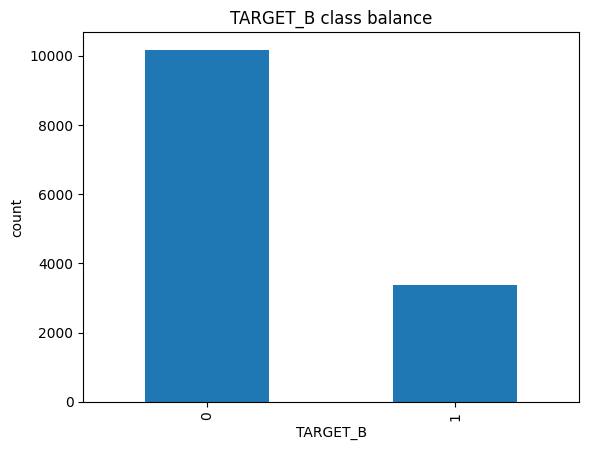

In [121]:
# Load the target and measure the class balance explicitly
target = pd.read_csv(train_target_path, index_col="CONTROL_NUMBER")

counts = target["TARGET_B"].value_counts().sort_index()
props  = target["TARGET_B"].value_counts(normalize=True).sort_index()
print("Class counts:\n", counts.to_string(), "\n")
print("Class proportions:\n", props.round(4).to_string(), "\n")

p = props.loc[1]                       # positive (donor) rate
trivial_all_ones_f1 = 2 * p / (1 + p)  # F1 of predicting "donor" for everyone
print(f"Positive (donor) rate: {p:.4f}")
print(f"Trivial 'predict-all-donors' F1 = {trivial_all_ones_f1:.4f}")

# Single visual (the only one needed here): class balance
counts.plot(kind="bar")
plt.title("TARGET_B class balance"); plt.xlabel("TARGET_B"); plt.ylabel("count"); plt.show()

### 2.2 Cleaning Strategy

The inspection revealed three kinds of problems:

1. **Hidden missing code** — `SES` and `URBANICITY` use the string `"?"` for unknown entries. We keep `"?"` as its own category (the EDA shows it is informative) rather than imputing it.
2. **Injected corruption** — every numeric column contains a few impossible *constant* values: negatives, non-integers in otherwise-integer columns, and proportions above 1.
3. **Sentinel values** — a `0` (or an implausibly low age) used as a hidden "missing" code where that value cannot occur.

All cleaning rules are **deterministic** (no fitting), so applying them identically to train and test causes **no leakage**; impossible values are mapped to `NaN` and imputed later, inside the CV pipeline.

We clean in **two passes**. The first removes the injected corruption (Rules 1–3). We then re-inspect the data and find that one problem survives — a `0` is a non-negative integer, so it slips through — which motivates a second pass (Rules 4–5).

#### First pass — injected corruption (Rules 1–3)

- **Rule 1** — negatives are impossible for any count / amount / age / income / month / percentage.
- **Rule 2** — a non-integer inside an integer-valued column is injected corruption (genuinely fractional columns — averages and proportions — are exempt).
- **Rule 3** — a proportion cannot exceed 1.

In [122]:
# Column groups defined by MEANING, not by dtype.
nominal_cat = ["DONOR_GENDER", "HOME_OWNER", "URBANICITY", "RECENCY_STATUS_96NK", "SES"]

# Genuinely fractional numeric columns (averages/proportions): non-integers are LEGITIMATE here.
fractional_num = ["RECENT_AVG_GIFT_AMT", "RECENT_AVG_CARD_GIFT_AMT",
                  "RECENT_RESPONSE_PROP", "RECENT_CARD_RESPONSE_PROP"]

# Proportions are bounded in [0, 1].
proportion_num = ["RECENT_RESPONSE_PROP", "RECENT_CARD_RESPONSE_PROP"]

def clean_impossible_values(df):
    """First pass: remove the injected corruption only (Rules 1-3). Deterministic -> no leakage."""
    df = df.copy()
    numeric_cols = df.select_dtypes("number").columns
    for col in numeric_cols:
        df.loc[df[col] < 0, col] = np.nan                                  # Rule 1: negatives
        if col not in fractional_num:                                      # Rule 2: non-integers in int cols
            df.loc[df[col].notna() & (df[col] % 1 != 0), col] = np.nan
    for col in proportion_num:                                             # Rule 3: proportions > 1
        df.loc[df[col] > 1, col] = np.nan
    return df

In [123]:
# Apply the first pass to the raw data.
train = clean_impossible_values(pd.read_csv(train_path, index_col="CONTROL_NUMBER"))
test  = clean_impossible_values(pd.read_csv(test_path,  index_col="CONTROL_NUMBER"))
print("First pass applied. train:", train.shape, "| test:", test.shape)

First pass applied. train: (13560, 39) | test: (5812, 39)


#### What survives the first pass

Rules 1–3 cannot catch a missing value coded as `0`, because `0` is a non-negative integer. Now that the injected negatives are gone, the **minimum** of the columns below is exactly `0` — which is impossible:

- the census fields (`MEDIAN_HOME_VALUE`, `MEDIAN_HOUSEHOLD_INCOME`, `PER_CAPITA_INCOME`): no real neighbourhood has a \$0 value;
- `LIFETIME_MIN_GIFT_AMT` / `LAST_GIFT_AMT`: every record gave at least one positive gift.

The same logic flags `DONOR_AGE` values below 18 as implausible for a mail-solicited donor.

In [124]:
# With the injected negatives removed, the minimum of these columns is now exactly 0 -- impossible.
impossible_zero = ["MEDIAN_HOME_VALUE", "MEDIAN_HOUSEHOLD_INCOME", "PER_CAPITA_INCOME",
                   "LIFETIME_MIN_GIFT_AMT", "LAST_GIFT_AMT"]
print("Minimum value still present after the first pass:")
for col in impossible_zero:
    n0 = int((train[col] == 0).sum())
    print(f"  {col:26s} min = {train[col].min():7.2f} | zeros = {n0:4d} ({n0/len(train)*100:4.1f}%)")

# Contradiction proof: these donors DID give, yet their min / last gift is 0.
gave_but_zero = train[(train["LIFETIME_MIN_GIFT_AMT"] == 0) | (train["LAST_GIFT_AMT"] == 0)]
print(f"\n{len(gave_but_zero)} donors have a 0 min/last gift, yet their lifetime giving stays positive:")
print(gave_but_zero[["LIFETIME_GIFT_COUNT", "LIFETIME_GIFT_AMOUNT"]].agg(["min", "max"]).T.round(2).to_string())

# The census zeros tend to co-occur -> a shared 'no census data' sentinel.
census = ["MEDIAN_HOME_VALUE", "MEDIAN_HOUSEHOLD_INCOME", "PER_CAPITA_INCOME"]
print(f"\nCensus zeros: {int((train[census] == 0).any(axis=1).sum())} rows with any of three, "
      f"{int((train[census] == 0).all(axis=1).sum())} with all three together.")

# DONOR_AGE: implausibly young records still remain.
print(f"\nDONOR_AGE still below 18: {int((train['DONOR_AGE'] < 18).sum())} records "
      f"(min = {train['DONOR_AGE'].min():.0f}).")

Minimum value still present after the first pass:
  MEDIAN_HOME_VALUE          min =    0.00 | zeros =  153 ( 1.1%)
  MEDIAN_HOUSEHOLD_INCOME    min =    0.00 | zeros =  118 ( 0.9%)
  PER_CAPITA_INCOME          min =    0.00 | zeros =  121 ( 0.9%)
  LIFETIME_MIN_GIFT_AMT      min =    0.00 | zeros =   72 ( 0.5%)
  LAST_GIFT_AMT              min =    0.00 | zeros =   47 ( 0.3%)

74 donors have a 0 min/last gift, yet their lifetime giving stays positive:
                       min    max
LIFETIME_GIFT_COUNT    1.0   48.0
LIFETIME_GIFT_AMOUNT  20.0  787.0

Census zeros: 157 rows with any of three, 114 with all three together.

DONOR_AGE still below 18: 132 records (min = 0).


#### Second pass — sentinel zeros and implausible ages (Rules 4–5)

- **Rule 4** — a `0` in the census and min/last-gift columns is a missing sentinel → `NaN`. (Card/recency metrics such as `FILE_CARD_GIFT`, `RECENT_AVG_CARD_GIFT_AMT`, `RECENT_AVG_GIFT_AMT` are left alone: there `0` legitimately means "no such activity".)
- **Rule 5** — a donor age below 18 is implausible → `NaN`.

We add these two rules to the cleaner and re-run it on the fresh raw data, so the final `train` / `test` are produced by a single, complete function.

In [125]:
# Columns where a value of 0 is IMPOSSIBLE -> missing/sentinel, mapped to NaN.
# (Distinct from card/recency metrics, where 0 legitimately means "no such activity" and is kept.)
zero_is_missing = ["MEDIAN_HOME_VALUE", "MEDIAN_HOUSEHOLD_INCOME", "PER_CAPITA_INCOME",
                   "LAST_GIFT_AMT", "LIFETIME_MIN_GIFT_AMT"]

def clean_impossible_values(df):
    """Full cleaner: injected corruption (Rules 1-3) + sentinel zeros & implausible ages (Rules 4-5).
    Deterministic -> applying it identically to train and test causes no leakage."""
    df = df.copy()
    numeric_cols = df.select_dtypes("number").columns
    for col in numeric_cols:
        df.loc[df[col] < 0, col] = np.nan                                  # Rule 1: negatives
        if col not in fractional_num:                                      # Rule 2: non-integers in int cols
            df.loc[df[col].notna() & (df[col] % 1 != 0), col] = np.nan
    for col in proportion_num:                                             # Rule 3: proportions > 1
        df.loc[df[col] > 1, col] = np.nan
    for col in zero_is_missing:                                            # Rule 4: sentinel zeros
        df.loc[df[col] == 0, col] = np.nan
    df.loc[df["DONOR_AGE"] < 18, "DONOR_AGE"] = np.nan                      # Rule 5: implausible ages (<18)
    return df

In [126]:
# Re-run the complete cleaner on fresh raw data (self-contained & re-runnable; "?" kept as a category).
train = clean_impossible_values(pd.read_csv(train_path, index_col="CONTROL_NUMBER"))
test  = clean_impossible_values(pd.read_csv(test_path,  index_col="CONTROL_NUMBER"))

# Feature-quality sanity checks (the target is attached later, in the modelling-setup step).
num_cols = train.select_dtypes("number").columns
print("Remaining negatives:", int((train[num_cols] < 0).sum().sum()))                              # expect 0
print("Remaining non-integers in integer cols:",
      int(sum((train[c].dropna() % 1 != 0).sum() for c in num_cols if c not in fractional_num)))    # expect 0
print("train shape:", train.shape, "| test shape:", test.shape)

Remaining negatives: 0
Remaining non-integers in integer cols: 0
train shape: (13560, 39) | test shape: (5812, 39)


In [127]:
# Verify Rules 4-5: sentinel zeros and under-18 ages are now NaN; legitimate zeros are untouched.
print("Zeros after cleaning:")
for c in ["MEDIAN_HOME_VALUE", "MEDIAN_HOUSEHOLD_INCOME", "PER_CAPITA_INCOME",
          "LAST_GIFT_AMT", "LIFETIME_MIN_GIFT_AMT",                                  # expect 0
          "FILE_CARD_GIFT", "RECENT_AVG_CARD_GIFT_AMT", "RECENT_AVG_GIFT_AMT"]:      # kept (legitimate)
    print(f"  {c:26s} zeros = {int((train[c] == 0).sum())}")
print(f"\nDONOR_AGE min after cleaning: {train['DONOR_AGE'].min()}  (expect >= 18)")

Zeros after cleaning:
  MEDIAN_HOME_VALUE          zeros = 0
  MEDIAN_HOUSEHOLD_INCOME    zeros = 0
  PER_CAPITA_INCOME          zeros = 0
  LAST_GIFT_AMT              zeros = 0
  LIFETIME_MIN_GIFT_AMT      zeros = 0
  FILE_CARD_GIFT             zeros = 646
  RECENT_AVG_CARD_GIFT_AMT   zeros = 2650
  RECENT_AVG_GIFT_AMT        zeros = 164

DONOR_AGE min after cleaning: 18.0  (expect >= 18)


In [128]:
# Range verification after cleaning, extended to ALL columns with a definable bound.
# Rules 1-3 catch corruption generically (non-integer / negative), so the only thing that could
# slip through is an in-range-looking INTEGER that is actually out of bounds. We check every column
# where a bound is meaningful; the rest get a min/max plausibility check.

# 1. Documented coded ranges (exact valid sets)
coded_valid = {
    "FREQUENCY_STATUS_97NK": set(range(1, 5)),    # 1-4
    "INCOME_GROUP":          set(range(1, 8)),    # 1-7
    "WEALTH_RATING":         set(range(0, 10)),   # 0-9
    "PEP_STAR":              {0, 1},
}
for col, valid in coded_valid.items():
    unexpected = set(train[col].dropna().unique()) - valid
    print(f"{col:26s} unexpected: {sorted(unexpected) if unexpected else 'none'}")

# 2. Percentages must lie in [0, 100]; proportions in [0, 1]
pct_cols  = ["PCT_ATTRIBUTE1", "PCT_ATTRIBUTE2", "PCT_ATTRIBUTE3", "PCT_ATTRIBUTE4", "PCT_OWNER_OCCUPIED"]
prop_cols = ["RECENT_RESPONSE_PROP", "RECENT_CARD_RESPONSE_PROP"]
for col in pct_cols:
    print(f"{col:26s} outside [0,100]: {int(((train[col] < 0) | (train[col] > 100)).sum())}")
for col in prop_cols:
    print(f"{col:26s} outside [0,1]  : {int(((train[col] < 0) | (train[col] > 1)).sum())}")

# 3. Unbounded columns (counts, amounts, ages, months, star counts): no fixed range -> min/max sanity
unbounded = [c for c in train.select_dtypes("number").columns
             if c not in coded_valid and c not in pct_cols and c not in prop_cols]
print("\nMin / max of unbounded numeric columns (plausibility check):")
print(train[unbounded].agg(["min", "max"]).T.round(2).to_string())

FREQUENCY_STATUS_97NK      unexpected: none
INCOME_GROUP               unexpected: none
WEALTH_RATING              unexpected: none
PEP_STAR                   unexpected: none
PCT_ATTRIBUTE1             outside [0,100]: 0
PCT_ATTRIBUTE2             outside [0,100]: 0
PCT_ATTRIBUTE3             outside [0,100]: 0
PCT_ATTRIBUTE4             outside [0,100]: 0
PCT_OWNER_OCCUPIED         outside [0,100]: 0
RECENT_RESPONSE_PROP       outside [0,1]  : 0
RECENT_CARD_RESPONSE_PROP  outside [0,1]  : 0

Min / max of unbounded numeric columns (plausibility check):
                                min       max
CARD_PROM_12                    1.0      17.0
CHILDREN                        0.0       4.0
DONOR_AGE                      18.0      87.0
FILE_CARD_GIFT                  0.0      32.0
LAST_GIFT_AMT                   1.0     450.0
LIFETIME_CARD_PROM              2.0      55.0
LIFETIME_GIFT_AMOUNT           15.0    3775.0
LIFETIME_GIFT_COUNT             1.0      95.0
LIFETIME_MAX_GIFT_AMT     

The verification confirms the cleaning worked: every coded/count column now contains only its valid
values plus `NaN`. In particular `FREQUENCY_STATUS_97NK` keeps only {1, 2, 3, 4} — its two corrupt
constants (`-1.365242`, `5.283869`) became `NaN`, caught by Rules 1 and 2. The "unexpected values =
none" lines also prove that no integer-but-out-of-range corruption slipped through, so Rules 1–3 are
sufficient and no explicit per-column range rule is needed.




## 3. Exploratory Data Analysis

With the data clean, we run a focused exploration that directly informs two preprocessing decisions:
the **missing-data mechanism** (which dictates the imputation strategy) and the meaning of the
explicit **`"?"` code in `SES`** (keep as a category vs. treat as missing).

### 3.1 Missingness Pattern

If values were missing completely at random, the missingness of one feature would not predict the
missingness of another. We therefore (a) measure how much each feature is missing and (b) test
whether missingness *co-occurs* across features. For `SES` and `URBANICITY` we count the explicit
`"?"` code as "unknown" alongside genuine `NaN`.

Missing / unknown per feature (%):
WEALTH_RATING                  47.2
DONOR_AGE                      28.5
INCOME_GROUP                   25.2
LIFETIME_GIFT_AMOUNT            4.7
LIFETIME_MIN_GIFT_AMT           4.4
SES                             4.3
URBANICITY                      4.2
MONTHS_SINCE_LAST_PROM_RESP     4.2
MEDIAN_HOME_VALUE               3.9
PER_CAPITA_INCOME               3.8
MEDIAN_HOUSEHOLD_INCOME         3.8
LAST_GIFT_AMT                   3.4
LIFETIME_MAX_GIFT_AMT           3.3
MONTHS_SINCE_FIRST_GIFT         3.1
RECENT_CARD_RESPONSE_COUNT      3.1
PCT_ATTRIBUTE3                  3.1
CHILDREN                        3.1
RECENT_STAR_STATUS              3.0
PCT_ATTRIBUTE4                  3.0
LIFETIME_CARD_PROM              3.0
LIFETIME_PROM                   3.0
MONTHS_SINCE_LAST_GIFT          3.0
NUMBER_PROM_12                  3.0
RECENT_RESPONSE_COUNT           2.9
CARD_PROM_12                    2.9
PCT_ATTRIBUTE1                  2.9
PCT_OWNER_OCCUPIED           

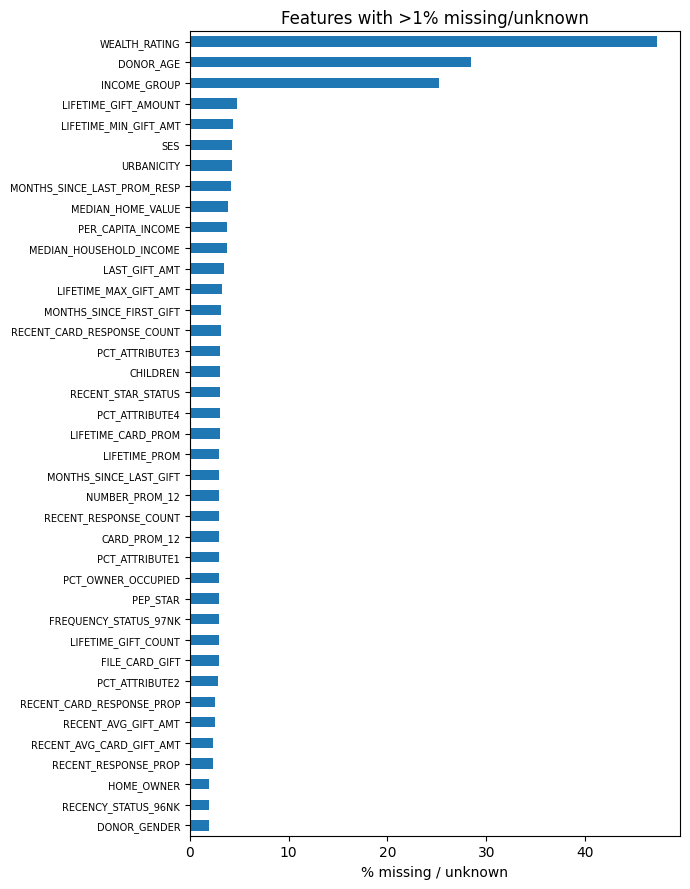

In [129]:
# Missingness per feature. For SES / URBANICITY the explicit "?" code is also "unknown",
# so we count it alongside genuine NaN (all other columns: NaN only).
unknown = train.isna().copy()
for c in ["SES", "URBANICITY"]:
    unknown[c] = train[c].isna() | (train[c] == "?")

miss_pct = (unknown.mean() * 100).sort_values(ascending=False)
print("Missing / unknown per feature (%):")
print(miss_pct[miss_pct > 0].round(1).to_string())

sub = miss_pct[miss_pct > 1]
ax = sub.plot(kind="barh", figsize=(7, 9))
ax.set_xlabel("% missing / unknown"); ax.set_title("Features with >1% missing/unknown")
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.show()

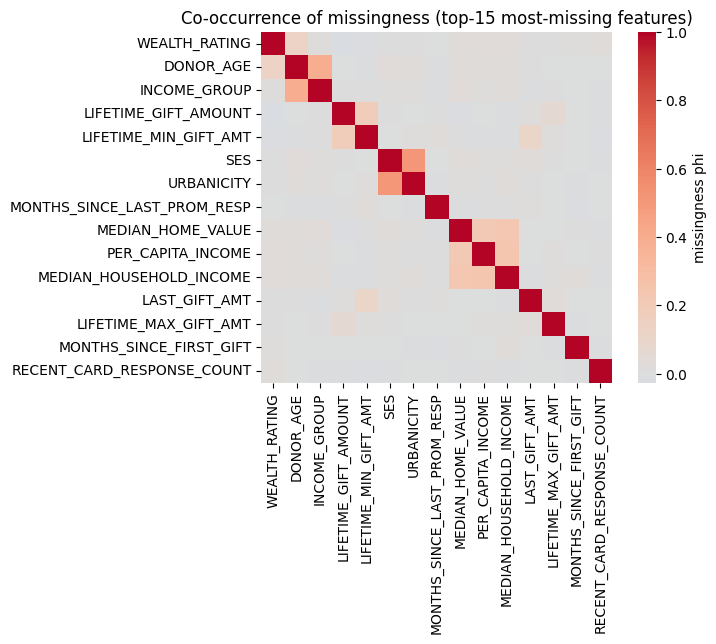

Strongest missingness correlations (phi):
SES                    URBANICITY                 0.51
DONOR_AGE              INCOME_GROUP               0.39
PER_CAPITA_INCOME      MEDIAN_HOUSEHOLD_INCOME    0.24
MEDIAN_HOME_VALUE      MEDIAN_HOUSEHOLD_INCOME    0.23
                       PER_CAPITA_INCOME          0.22
LIFETIME_GIFT_AMOUNT   LIFETIME_MIN_GIFT_AMT      0.18
WEALTH_RATING          DONOR_AGE                  0.13
LIFETIME_MIN_GIFT_AMT  LAST_GIFT_AMT              0.11

SES & URBANICITY both unknown: observed = 307, expected if independent = 24


In [130]:
# Is missingness random? Correlate the missingness indicators of the most-affected features.
miss_cols = miss_pct.sort_values(ascending=False).head(15).index.tolist()
corr = unknown[miss_cols].astype(int).corr()          # phi = correlation of binary indicators

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"label": "missingness phi"})
plt.title("Co-occurrence of missingness (top-15 most-missing features)")
plt.tight_layout(); plt.show()

# Concrete evidence: the strongest co-occurring pairs.
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print("Strongest missingness correlations (phi):")
print(pairs.head(8).round(2).to_string())

# Top pair quantified against the independence baseline.
a, b = unknown["SES"], unknown["URBANICITY"]
print(f"\nSES & URBANICITY both unknown: observed = {int((a & b).sum())}, "
      f"expected if independent = {a.mean() * b.mean() * len(train):.0f}")

### 3.2 The `SES` `"?"` Code

`SES` is documented as 5 demographic profiles but stored as `1, 2, 3, 4` plus the code `"?"` — and
the 5th profile is never labelled. Is `"?"` that missing 5th profile (a real, distinct group), or
just unrecorded data? We profile every `SES` value (including `"?"` and genuine `NaN`) against the
response rate and a few descriptive features, comparing each to the population average (`ALL`).

In [131]:
# Profile each SES group (including "?" and genuine NaN) to see whether "?" behaves like a distinct
# segment or like representative missing data. TARGET_B is used here for exploration only.
ses_view = train.join(target).copy()
ses_view["SES"] = ses_view["SES"].fillna("NaN")

feats = ["TARGET_B", "PCT_ATTRIBUTE2", "PCT_ATTRIBUTE3", "PCT_ATTRIBUTE4",
         "MEDIAN_HOUSEHOLD_INCOME", "WEALTH_RATING"]
prof = ses_view.groupby("SES")[feats].mean()
prof.insert(0, "n", ses_view.groupby("SES").size())
prof.loc["ALL"] = [len(ses_view)] + ses_view[feats].mean().tolist()
print(prof.round(2).to_string())

           n  TARGET_B  PCT_ATTRIBUTE2  PCT_ATTRIBUTE3  PCT_ATTRIBUTE4  MEDIAN_HOUSEHOLD_INCOME  WEALTH_RATING
SES                                                                                                           
1     4091.0      0.27           31.65           32.04           33.46                   483.47           7.42
2     6365.0      0.26           32.57           30.71           33.56                   303.96           4.49
3     2277.0      0.22           28.32           26.66           33.86                   226.78           2.44
4      249.0      0.17           20.85           22.96           31.23                   206.35           1.45
?      292.0      0.26            3.50            2.69            3.90                   350.89           5.03
NaN    286.0      0.22           29.53           28.93           31.50                   349.53           5.20
ALL  13560.0      0.25           30.67           29.65           32.86                   345.79           5.01


In [132]:
# Same question for URBANICITY, which also uses "?". Urbanicity should track housing/density, so we
# profile owner-occupancy, home value and income (plus a veteran share, to compare with the SES
# finding). TARGET_B is used here for exploration only.
urb_view = train.join(target).copy()
urb_view["URBANICITY"] = urb_view["URBANICITY"].fillna("NaN")

feats_u = ["TARGET_B", "PCT_OWNER_OCCUPIED", "MEDIAN_HOME_VALUE", "PER_CAPITA_INCOME", "PCT_ATTRIBUTE2"]
prof_u = urb_view.groupby("URBANICITY")[feats_u].mean()
prof_u.insert(0, "n", urb_view.groupby("URBANICITY").size())
prof_u.loc["ALL"] = [len(urb_view)] + urb_view[feats_u].mean().tolist()
print(prof_u.round(2).to_string())

# Do the "?" codes of SES and URBANICITY mark the same rows?
both_q = int(((train["SES"] == "?") & (train["URBANICITY"] == "?")).sum())
print(f"\nRows with SES == '?' AND URBANICITY == '?': {both_q}  "
      f"(SES '?' = {int((train['SES'] == '?').sum())}, URBANICITY '?' = {int((train['URBANICITY'] == '?').sum())})")

                  n  TARGET_B  PCT_OWNER_OCCUPIED  MEDIAN_HOME_VALUE  PER_CAPITA_INCOME  PCT_ATTRIBUTE2
URBANICITY                                                                                             
?             295.0      0.25               69.11            1120.23           16105.72            3.46
C            2741.0      0.25               65.20            1009.55           16363.61           33.87
NaN           278.0      0.24               68.90            1045.23           15724.50           29.74
R            2732.0      0.23               76.64             580.58           11496.74           31.09
S            3103.0      0.27               72.16            1502.86           20266.62           31.18
T            2734.0      0.26               73.12             863.72           14740.82           32.55
U            1677.0      0.24               55.44            1687.25           17535.91           25.72
ALL         13560.0      0.25               69.64            109

**Findings.** Two regimes emerge. Almost every feature sits on a flat ~2-3% floor (e.g. `DONOR_GENDER`
1.9%, `PEP_STAR` 2.9%), consistent with the injected corruption being scattered at random (MCAR).
Three features rise far above it: `WEALTH_RATING` (47%), `DONOR_AGE` (28%) and `INCOME_GROUP` (25%).

Missingness is not globally random: it co-occurs in interpretable blocks. The strongest pair is
`SES`–`URBANICITY` (phi = 0.51) — 307 records have both unknown against only ~24 expected under
independence, a ~13x excess. Three weaker blocks follow: a demographic one (`DONOR_AGE`–`INCOME_GROUP`
0.39, `WEALTH_RATING`–`DONOR_AGE` 0.13), a neighbourhood-income one (`MEDIAN_HOUSEHOLD_INCOME`,
`PER_CAPITA_INCOME`, `MEDIAN_HOME_VALUE`, phi 0.22-0.24), and a gift one
(`LIFETIME_GIFT_AMOUNT`–`LIFETIME_MIN_GIFT_AMT` 0.18).

**Implication for imputation.** The low-rate floor is plausibly MCAR (Missing Completely At Random), so a simple per-column imputer is
adequate there. But the heavily-missing structural fields — above all `WEALTH_RATING`, absent for ~half
the donors — go missing *together with* the demographic/income block they belong to, so they are not
MCAR. Replacing them with a single column statistic ignores that structure. This is why we do not
commit to simple imputation now: later we test a multivariate, model-based imputer (`IterativeImputer` /
MICE) that reconstructs a field from the correlated fields observed for the same record.

**Findings.** `SES 1→4` is an ordinal socioeconomic gradient: from `SES 1` (median household income
483, wealth 7.4, response 0.27) down to `SES 4` (income 206, wealth 1.5, response 0.17) — so SES is
both ordered and predictive of the response rate.

The `"?"` code is **not** missing data: it is a distinct, identifiable segment. 284 of the ~292
`SES = "?"` records also carry `URBANICITY = "?"`, so the two columns flag essentially the *same* ~290
donors. That subpopulation is economically average — income, wealth, home value, owner-occupancy and
response rate all sit on the population mean — yet its neighbourhoods have almost no veterans:
`PCT_ATTRIBUTE2/3/4` collapse to ~3-4% against ~30% everywhere else. A genuinely-random gap could not
produce such a sharp, consistent signature across both columns.

By contrast, the genuine `NaN` groups (286 in SES, 278 in URBANICITY) track the population average on
every feature, exactly as representative missing data should.

**Decision.** We keep `"?"` as its own one-hot category in both `SES` and `URBANICITY` (it carries real
signal) and impute only the genuine `NaN` (most-frequent). Note that although `SES 1-4` is ordinal,
`"?"` sits off that scale, so one-hot encoding is the natural choice: it represents the distinct profile
without forcing it onto the 1-4 axis.

## 4. Preprocessing & Model Assessment

We now turn the clean data into a model-ready, leakage-free pipeline and fix the assessment protocol
used for every later comparison.

**Why impute rather than drop the missing values?** Listwise deletion (keeping only fully-observed
rows) is unbiased *only* under MCAR — but Section 3.1 showed the heavy missingness is structured (MAR),
so dropping those rows would systematically distort the training sample. It is also impossible in
practice: the test set carries the same missingness and we must output a prediction for *every* test
row, so an imputation strategy is required regardless. The cell below quantifies how costly deletion
would be.

In [133]:
# How costly / feasible is complete-case analysis (dropping any row with a NaN)?
na_per_row = train.isna().sum(axis=1)
complete = int((na_per_row == 0).sum())
print(f"Train rows with no NaN: {complete} / {len(train)} ({complete/len(train)*100:.1f}%)")
print(f"NaN per row — min {int(na_per_row.min())}, median {int(na_per_row.median())}, max {int(na_per_row.max())}")
print(f"WEALTH_RATING alone missing for {train['WEALTH_RATING'].isna().mean()*100:.0f}% of rows.")
print(f"Test rows with no NaN: {int((test.isna().sum(axis=1) == 0).sum())} / {len(test)} "
      f"(must still predict for all {len(test)}).")

Train rows with no NaN: 1588 / 13560 (11.7%)
NaN per row — min 0, median 2, max 9
WEALTH_RATING alone missing for 47% of rows.
Test rows with no NaN: 721 / 5812 (must still predict for all 5812).


In [134]:
# Attach the target by CONTROL_NUMBER and split into features X / label y.
modelling = train.join(target)
assert modelling["TARGET_B"].notna().all(), "Some feature rows have no matching target."
X = modelling.drop(columns="TARGET_B")
y = modelling["TARGET_B"].astype(int)
numeric_cols_X = [c for c in X.columns if c not in nominal_cat]
print("X:", X.shape, "| positive rate:", round(y.mean(), 4))

X: (13560, 39) | positive rate: 0.25


In [135]:
def make_preprocessor(numeric_imputer):
    """Numeric: impute (swappable) + scale.  Categorical: most_frequent + one-hot (keeps "?" as a category)."""
    num_pipe = Pipeline([("impute", numeric_imputer),
                         ("scale",  MinMaxScaler())])
    cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                         ("ohe",    OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num_pipe, numeric_cols_X),
                              ("cat", cat_pipe, nominal_cat)])

# Baseline: simple median imputation. We later swap in IterativeImputer (MICE) and measure the gain,
# via make_preprocessor(IterativeImputer(random_state=RANDOM_SEED)).
preprocessor = make_preprocessor(SimpleImputer(strategy="median"))

In [136]:
# Assessment standard reused everywhere: stratified 5-fold CV (preserves the 25% positive rate per fold).
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def best_f1_threshold(y_true, proba):
    """Probability threshold (and its F1) that maximises binary F1 on (y_true, proba)."""
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)   # prec/rec have one extra point vs thr
    best = int(np.nanargmax(f1[:-1]))           # last point has no threshold -> drop it
    return thr[best], f1[best]

### Metric strategy

The competition scores **binary F1**, but F1 depends on a decision threshold, and the default 0.5 is
arbitrary: on a 25%-positive problem most models score the majority of true positives below 0.5, so
F1 0.5 understates the achievable F1 and is unstable across models. We therefore separate two
questions:

- *Is the model's ranking of donors good?* — judged with a threshold-independent metric, **average
  precision (PR-AUC)**, the area under the precision–recall curve, which is the appropriate summary for
  imbalanced data. This is the objective we tune hyperparameters on.
- *Where do we cut?* — once a model is fitted, the operating threshold is chosen to maximise F1 on
  out-of-fold predictions via `best_f1_threshold`.

When PR-AUC and tuned-F1 disagree on the best model, we decide on **tuned-F1** (the competition metric);
PR-AUC is used as the search objective because it is stable and threshold-free.

## 5. Feature Selection

No single criterion is reliable on its own, so we rank features with **six methods across three
families** and keep what they agree on:

- *Filter* — Spearman |correlation| with the target (monotonic association) and mutual information
  (non-linear association).
- *Statistical* — the chi-squared score (association with the target on non-negative, scaled inputs).
- *Embedded* — L1-penalised logistic regression (sparse coefficients) and decision-tree impurity importance.
- *Wrapper* — recursive feature elimination (RFE) with a logistic estimator.

Two caveats: decision-tree impurity importance is biased toward continuous, high-cardinality features
and understates low-cardinality codes; L1 logistic tends to be non-discriminating here (it keeps almost
everything). We therefore trust **consensus**, especially agreement between a filter (MI/Spearman) and
the wrapper (RFE).

Everything is computed **per fold** of the stratified 5-fold split, with the **IterativeImputer fitted
inside each fold** — both to avoid leakage and because mean imputation would deflate the
very correlations these filters measure. Categorical features are scored by aggregating across their
one-hot columns (max). A feature passes a method if it is top-half in a majority of folds (≥3/5); the
number of methods passed (0-6) gives a KEEP / TRY / DROP label, which we finalise after inspecting the
table.

In [137]:
# --- Feature-selection helpers --------------------------------------------------------------------
from sklearn.feature_selection import chi2   # (can be moved to the grouped imports cell)

def transformed_names_and_origin(fitted_ct):
    """Transformed-column names and a map back to the ORIGINAL feature."""
    ohe = fitted_ct.named_transformers_["cat"].named_steps["ohe"]
    cat_names = list(ohe.get_feature_names_out(nominal_cat))
    names = list(numeric_cols_X) + cat_names          # ColumnTransformer order: num block, then cat block
    origin = {c: c for c in numeric_cols_X}
    for cn in cat_names:
        origin[cn] = next(c for c in nominal_cat if cn.startswith(c + "_"))
    return names, origin

def fold_feature_scores(Z, y):
    """Per-(transformed-column) importance for six methods (higher = more important)."""
    p = Z.shape[1]
    s = {}
    s["spearman"]    = np.array([abs(np.nan_to_num(spearmanr(Z[:, j], y).correlation)) for j in range(p)])
    s["mutual_info"] = mutual_info_classif(Z, y, random_state=RANDOM_SEED)
    s["chi2"]        = np.nan_to_num(chi2(Z, y)[0])
    s["l1_logistic"] = np.abs(LogisticRegression(penalty="l1", solver="liblinear",
                                                 C=1.0, max_iter=1000).fit(Z, y).coef_).ravel()
    s["tree"]        = DecisionTreeClassifier(random_state=RANDOM_SEED).fit(Z, y).feature_importances_
    rfe = RFE(LogisticRegression(solver="liblinear", max_iter=1000),
              n_features_to_select=max(1, p // 2)).fit(Z, y)
    s["rfe"]         = (rfe.ranking_.max() - rfe.ranking_).astype(float)
    return s

def aggregate_to_original(score, names, origin):
    """Reduce transformed-column scores to one score per original feature (max over its OHE columns)."""
    agg = {}
    for j, nm in enumerate(names):
        f = origin[nm]
        agg[f] = max(agg.get(f, 0.0), score[j])
    return pd.Series(agg)

In [138]:
# Per-fold, multi-method feature ranking; IterativeImputer fitted INSIDE each fold (no leakage).
# A feature "passes" a method if it is top-half in a majority of folds (>=3/5).
# NOTE: runs IterativeImputer 5x -> expect a few minutes (and harmless convergence warnings).
methods = ["spearman", "mutual_info", "chi2", "l1_logistic", "tree", "rfe"]
all_features = numeric_cols_X + nominal_cat
fold_passes = pd.DataFrame(0, index=all_features, columns=methods)   # folds where feature was top-half

for tr_idx, _ in skf.split(X, y):
    Xf, yf = X.iloc[tr_idx], y.iloc[tr_idx]
    ct = make_preprocessor(IterativeImputer(random_state=RANDOM_SEED)).fit(Xf, yf)
    Z = ct.transform(Xf)
    if hasattr(Z, "toarray"):
        Z = Z.toarray()
    names, origin = transformed_names_and_origin(ct)
    scores = fold_feature_scores(Z, yf.values)
    for m in methods:
        ranked = aggregate_to_original(scores[m], names, origin).rank(ascending=False)
        top_half = ranked[ranked <= len(all_features) / 2].index
        fold_passes.loc[top_half, m] += 1

summary = (fold_passes >= 3).astype(int)                       # majority-of-folds pass per method
summary["votes"] = summary.sum(axis=1)
summary["decision"] = np.where(summary["votes"] >= 5, "KEEP",
                       np.where(summary["votes"] >= 3, "TRY", "DROP"))
print(summary.sort_values("votes", ascending=False).to_string())

/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings

                             spearman  mutual_info  chi2  l1_logistic  tree  rfe  votes decision
RECENT_RESPONSE_PROP                1            1     1            1     1    1      6     KEEP
LIFETIME_CARD_PROM                  1            1     1            1     1    1      6     KEEP
MONTHS_SINCE_LAST_GIFT              1            1     1            1     1    1      6     KEEP
MONTHS_SINCE_FIRST_GIFT             1            0     1            1     1    1      5     KEEP
RECENT_RESPONSE_COUNT               1            1     1            1     0    1      5     KEEP
FREQUENCY_STATUS_97NK               1            1     1            1     0    1      5     KEEP
RECENT_AVG_GIFT_AMT                 1            1     0            1     1    1      5     KEEP
RECENT_CARD_RESPONSE_COUNT          1            1     1            1     0    1      5     KEEP
RECENCY_STATUS_96NK                 1            1     1            1     0    1      5     KEEP
RECENT_CARD_RESPONSE_PROP     

**Findings.** Eleven features reach a broad consensus (≥5/6 methods) and form the KEEP set; they are
almost all **engagement / recency / frequency** signals — response proportions and counts, months
since last/first gift, frequency and recency status, card-promotion history, recent average gift and
STAR status — exactly the behavioural history one expects to predict a donation.

The two caveats are visible in the table. The decision tree casts **lone votes** for continuous
features no filter or wrapper supports (`DONOR_AGE`, `WEALTH_RATING`, `PER_CAPITA_INCOME`,
`PCT_ATTRIBUTE2/3`) — the impurity bias toward high-cardinality variables — while it **misses** strong
low-cardinality codes every other method keeps (`FREQUENCY_STATUS_97NK`, `RECENCY_STATUS_96NK`,
`PEP_STAR`). We therefore discount tree-only votes. L1 logistic, in contrast, behaved selectively here
and tracked the consensus.

Twelve mid-ranked features (3-4 votes) form the TRY set — mostly the **demographic / wealth** block
(`INCOME_GROUP`, `SES`, `URBANICITY`, `MEDIAN_HOME_VALUE`, `MEDIAN_HOUSEHOLD_INCOME`) and **lifetime
giving** aggregates (`LIFETIME_PROM`, `LIFETIME_GIFT_COUNT/AMOUNT/MIN_GIFT_AMT`, `LAST_GIFT_AMT`). They
carry secondary signal that is partly redundant with KEEP, so rather than include them blindly we test
them later in a wrapper step (does adding them improve cross-validated F1?). The rest are dropped:
their only support is the biased tree, or no method at all.

In [139]:
# Consensus feature sets from the vote table (>=5 -> KEEP; 3-4 -> TRY; the rest dropped).
keep_features = [
    "RECENT_RESPONSE_PROP", "MONTHS_SINCE_LAST_GIFT", "LIFETIME_CARD_PROM",
    "MONTHS_SINCE_FIRST_GIFT", "FREQUENCY_STATUS_97NK", "RECENT_CARD_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_PROP", "RECENT_AVG_GIFT_AMT", "RECENCY_STATUS_96NK",
    "PEP_STAR", "RECENT_RESPONSE_COUNT",
]
try_features = [
    "LAST_GIFT_AMT", "INCOME_GROUP", "SES", "LIFETIME_PROM", "MEDIAN_HOME_VALUE",
    "MONTHS_SINCE_LAST_PROM_RESP", "MEDIAN_HOUSEHOLD_INCOME", "LIFETIME_GIFT_COUNT",
    "URBANICITY", "PCT_ATTRIBUTE4", "LIFETIME_MIN_GIFT_AMT", "LIFETIME_GIFT_AMOUNT",
]
print(f"KEEP: {len(keep_features)} | TRY: {len(try_features)} | "
      f"DROP: {len(all_features) - len(keep_features) - len(try_features)}")

KEEP: 11 | TRY: 12 | DROP: 16


### 5.1 Redundancy among Candidates

Filter scores rank each feature's *individual* signal and, by design, ignore redundancy — so the
consensus set above contains correlated pairs (e.g. response *count* vs *proportion*). We surface them
with Spearman correlation among the numeric candidates (imputed once with IterativeImputer; feature→
feature, no target). We do **not** drop on correlation alone: two correlated features can still add
joint signal, so the strongly-correlated pairs below are flagged as targets for the wrapper step, which
decides — on cross-validated F1 — whether keeping both is worth it. Categorical overlaps
(`RECENCY_STATUS_96NK` with recency/frequency, `SES`/`URBANICITY` with the income block) are left to the
wrapper as well.

Strongly correlated candidate pairs (|Spearman| >= 0.7):
LIFETIME_CARD_PROM          LIFETIME_PROM                  0.97
                            MONTHS_SINCE_FIRST_GIFT        0.93
MONTHS_SINCE_FIRST_GIFT     LIFETIME_PROM                  0.91
LIFETIME_PROM               LIFETIME_GIFT_COUNT            0.88
LIFETIME_CARD_PROM          LIFETIME_GIFT_COUNT            0.88
LIFETIME_PROM               LIFETIME_GIFT_AMOUNT           0.87
MONTHS_SINCE_LAST_GIFT      MONTHS_SINCE_LAST_PROM_RESP    0.86
LIFETIME_CARD_PROM          LIFETIME_GIFT_AMOUNT           0.86
MONTHS_SINCE_FIRST_GIFT     LIFETIME_GIFT_COUNT            0.85
RECENT_AVG_GIFT_AMT         LAST_GIFT_AMT                  0.84
LIFETIME_GIFT_COUNT         LIFETIME_GIFT_AMOUNT           0.84
RECENT_CARD_RESPONSE_COUNT  RECENT_CARD_RESPONSE_PROP      0.83
MONTHS_SINCE_FIRST_GIFT     LIFETIME_GIFT_AMOUNT           0.78
FREQUENCY_STATUS_97NK       RECENT_RESPONSE_COUNT          0.78
RECENT_CARD_RESPONSE_COUNT  RECENT_RESPONSE_COU

/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


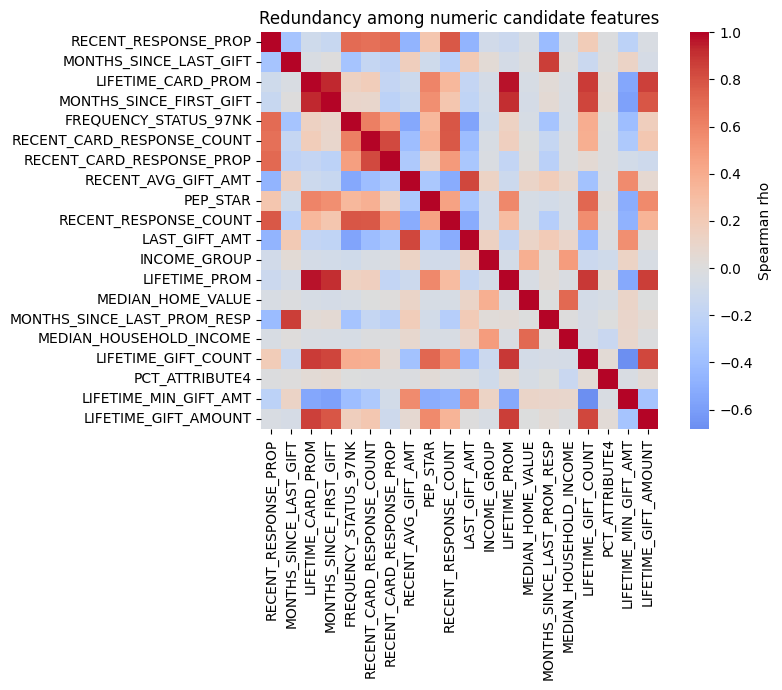

In [140]:
# Redundancy diagnostic: Spearman among numeric candidate features (KEEP + TRY).
# Imputed once with IterativeImputer on the full numeric block (exploratory; feature->feature, no target).
num_candidates = [f for f in keep_features + try_features if f in numeric_cols_X]
imp = IterativeImputer(random_state=RANDOM_SEED).fit(X[numeric_cols_X])
num_imp = pd.DataFrame(imp.transform(X[numeric_cols_X]), columns=numeric_cols_X, index=X.index)

rho = num_imp[num_candidates].corr(method="spearman")

# Strongly correlated pairs (|rho| >= 0.7) -> redundancy candidates for the wrapper to arbitrate.
pairs = rho.where(np.triu(np.ones(rho.shape), k=1).astype(bool)).stack()
strong = pairs[pairs.abs() >= 0.7]
strong = strong.reindex(strong.abs().sort_values(ascending=False).index)
print("Strongly correlated candidate pairs (|Spearman| >= 0.7):")
print(strong.round(2).to_string() if len(strong) else "  none above 0.7")

plt.figure(figsize=(9, 7))
sns.heatmap(rho, cmap="coolwarm", center=0, square=True, cbar_kws={"label": "Spearman rho"})
plt.title("Redundancy among numeric candidate features"); plt.tight_layout(); plt.show()

**Findings.** The candidates form a few redundancy clusters rather than isolated pairs:

- **Lifetime tenure/volume** (ρ 0.84-0.97): `LIFETIME_CARD_PROM`, `LIFETIME_PROM`, `LIFETIME_GIFT_COUNT`,
  `LIFETIME_GIFT_AMOUNT`, `MONTHS_SINCE_FIRST_GIFT` — near-interchangeable proxies for how long and how
  heavily a donor has been engaged. Two are in KEEP (`LIFETIME_CARD_PROM`, `MONTHS_SINCE_FIRST_GIFT`,
  ρ=0.93), so KEEP already carries internal redundancy here.
- **Recent responsiveness** (ρ 0.71-0.83): `RECENT_RESPONSE_PROP`, `RECENT_RESPONSE_COUNT`,
  `RECENT_CARD_RESPONSE_PROP`, `RECENT_CARD_RESPONSE_COUNT`, `FREQUENCY_STATUS_97NK` — all in KEEP, with
  the count↔proportion pairs most redundant; the densest overlap in the consensus set.
- **Recency** (ρ 0.86): `MONTHS_SINCE_LAST_GIFT` (KEEP) ↔ `MONTHS_SINCE_LAST_PROM_RESP` (TRY).
- **Gift amount** (ρ 0.84): `RECENT_AVG_GIFT_AMT` (KEEP) ↔ `LAST_GIFT_AMT` (TRY).
- **Neighbourhood income** (ρ 0.71): `MEDIAN_HOME_VALUE` ↔ `MEDIAN_HOUSEHOLD_INCOME` (both TRY).

`PEP_STAR` is only loosely tied to the lifetime cluster (ρ 0.72) and is a distinct binary STAR flag, so we
keep it separate.

**Plan.** Most TRY features are redundant with a KEEP member, and KEEP itself is over-complete in the two
behavioural clusters. Rather than prune by hand, we let the wrapper arbitrate on cross-validated score:
a sequential selector over the full candidate pool retains ~one representative per cluster, and we compare
its subset against the full consensus set on CV F1. We expect the recent-responsiveness cluster to collapse
to a couple of representatives and the lifetime cluster to one.

## 6. Feature Engineering

The redundancy clusters above suggest several raw features are better expressed as **relationships** than
kept individually. We add 12 row-wise, **stateless** features (each is a function of a single row, so the
same formula on train and test introduces no leakage). They fall into two groups.

**Behavioural ratios and composites** turn correlated raw counts/amounts into rate-of-… signals:

- `LIFETIME_RESPONSE_RATE` = gifts / promotions — conversion efficiency, decoupled from sheer volume.
- `RELATIVE_RECENCY` = months since last gift / months since first — recency relative to tenure.
- `AVG_LIFETIME_GIFT` = lifetime amount / lifetime count — typical generosity per gift.
- `GIFT_TREND` = last gift / recent average — is the latest gift above or below recent behaviour.
- `GIFT_VS_MAX` = last gift / lifetime maximum — momentum against the donor's best gift.
- `RFM_COMPOSITE` = frequency × recent avg gift / months since last gift — a classic Recency–Frequency–
  Monetary engagement score that compresses the dense recent-responsiveness cluster into one signal.

**Log transforms** (`log1p`) tame the heavy right skew of monetary and count variables
(`RECENT_AVG_GIFT_AMT`, `LIFETIME_GIFT_AMOUNT`, `MEDIAN_HOME_VALUE`, `PER_CAPITA_INCOME`,
`LIFETIME_GIFT_COUNT`, `LIFETIME_PROM`), which helps the linear and distance-based models.

Ratios whose denominator is zero are set to `NaN` (undefined) and imputed inside the pipeline like any
other missing value. These engineered features join the candidate pool; the wrapper (next section) decides
on cross-validated F1 whether each earns its place against the raw features.

In [141]:
def add_engineered_features(df):
    """Row-wise, stateless features (no fitting -> identical on train/test, no leakage)."""
    df = df.copy()
    with np.errstate(divide="ignore", invalid="ignore"):          # x/0 -> inf, handled below
        df["LIFETIME_RESPONSE_RATE"] = df["LIFETIME_GIFT_COUNT"] / df["LIFETIME_PROM"]
        df["RELATIVE_RECENCY"]       = df["MONTHS_SINCE_LAST_GIFT"] / df["MONTHS_SINCE_FIRST_GIFT"]
        df["AVG_LIFETIME_GIFT"]      = df["LIFETIME_GIFT_AMOUNT"] / df["LIFETIME_GIFT_COUNT"]
        df["GIFT_TREND"]             = df["LAST_GIFT_AMT"] / df["RECENT_AVG_GIFT_AMT"]
        df["GIFT_VS_MAX"]            = df["LAST_GIFT_AMT"] / df["LIFETIME_MAX_GIFT_AMT"]
        df["RFM_COMPOSITE"]          = (df["FREQUENCY_STATUS_97NK"] * df["RECENT_AVG_GIFT_AMT"]
                                        / df["MONTHS_SINCE_LAST_GIFT"])
    for col in ["RECENT_AVG_GIFT_AMT", "LIFETIME_GIFT_AMOUNT", "MEDIAN_HOME_VALUE",
                "PER_CAPITA_INCOME", "LIFETIME_GIFT_COUNT", "LIFETIME_PROM"]:
        df["LOG_" + col] = np.log1p(df[col].clip(lower=0))
    df = df.replace([np.inf, -np.inf], np.nan)                    # division by zero -> undefined -> NaN
    return df

# Add the engineered features to both train and test; they become part of the numeric candidate pool.
X    = add_engineered_features(X)
test = add_engineered_features(test)
numeric_cols_X = [c for c in X.columns if c not in nominal_cat]   # now includes the engineered features

engineered_features = ["LIFETIME_RESPONSE_RATE", "RELATIVE_RECENCY", "AVG_LIFETIME_GIFT", "GIFT_TREND",
                       "GIFT_VS_MAX", "RFM_COMPOSITE", "LOG_RECENT_AVG_GIFT_AMT", "LOG_LIFETIME_GIFT_AMOUNT",
                       "LOG_MEDIAN_HOME_VALUE", "LOG_PER_CAPITA_INCOME", "LOG_LIFETIME_GIFT_COUNT",
                       "LOG_LIFETIME_PROM"]
print(f"Added {len(engineered_features)} features. X now: {X.shape}")
print("Any inf left:", bool(np.isinf(X[numeric_cols_X].to_numpy(dtype=float)).any()))
print("NaN in engineered columns:\n" + X[engineered_features].isna().sum().to_string())

Added 12 features. X now: (13560, 51)
Any inf left: False
NaN in engineered columns:
LIFETIME_RESPONSE_RATE       792
RELATIVE_RECENCY             814
AVG_LIFETIME_GIFT           1018
GIFT_TREND                   951
GIFT_VS_MAX                  881
RFM_COMPOSITE               1109
LOG_RECENT_AVG_GIFT_AMT      343
LOG_LIFETIME_GIFT_AMOUNT     643
LOG_MEDIAN_HOME_VALUE        528
LOG_PER_CAPITA_INCOME        512
LOG_LIFETIME_GIFT_COUNT      398
LOG_LIFETIME_PROM            405


In [142]:
# Exploratory: do the engineered features carry signal? |Spearman| with target (median-imputed for ranking).
eng = X[engineered_features].fillna(X[engineered_features].median())
assoc = eng.apply(lambda s: abs(spearmanr(s, y).correlation)).sort_values(ascending=False)
print("Engineered features — |Spearman| with target:")
print(assoc.round(3).to_string())

Engineered features — |Spearman| with target:
LIFETIME_RESPONSE_RATE      0.120
LOG_RECENT_AVG_GIFT_AMT     0.106
LOG_LIFETIME_GIFT_COUNT     0.104
AVG_LIFETIME_GIFT           0.100
GIFT_VS_MAX                 0.085
RELATIVE_RECENCY            0.085
LOG_LIFETIME_PROM           0.060
RFM_COMPOSITE               0.054
LOG_LIFETIME_GIFT_AMOUNT    0.053
LOG_MEDIAN_HOME_VALUE       0.050
LOG_PER_CAPITA_INCOME       0.042
GIFT_TREND                  0.020


**Findings.** The engineered columns carry 343-1,109 missing values: ratios inherit `NaN` from each of
their ingredients (so the three-way `RFM_COMPOSITE` has the most) plus the zero-denominator cases set to
`NaN` above; the single-column logs have fewer. All are imputed inside the pipeline like any other gap.

The associations are modest (|Spearman| ≤ 0.12), as expected for this hard, low-signal target — no single
feature is strong, which is exactly why we combine many features and tune the decision threshold. Two
readings matter:

- `LIFETIME_RESPONSE_RATE` (0.12) is the strongest engineered signal and a genuinely **new** one: a
  conversion *rate* (gifts per solicitation) that no single raw feature captures — the main payoff of the
  engineering. `AVG_LIFETIME_GIFT` and the recency/amount ratios add weaker but plausible signal, while
  `GIFT_TREND` (0.02) is essentially flat and likely to be dropped by the wrapper.
- The `LOG_*` features show the **same** |Spearman| as their raw counterparts, because Spearman is a rank
  correlation and `log1p` is monotonic. Their benefit is therefore invisible to this check: it lies in
  **linearising** a skewed relationship for the logistic model and in **compressing outliers** for scaling
  and distance-based models, not in the rank association.

These are candidates, not commitments: the wrapper in the next section decides — on cross-validated F1 —
which engineered and raw features earn a place, resolving the redundancy clusters at the same time.

## 7. Modeling & Optimization

Every model is assessed with one protocol: a pipeline (subset-aware preprocessing → classifier) is run
with stratified 5-fold cross-validation to produce **out-of-fold** probabilities; from those we report
**PR-AUC** (threshold-free, for ranking quality) and the **F1 at the OOF-optimal threshold** (the
competition metric). The imputer lives inside the pipeline, so it is refitted on each training fold —
no leakage. We use this harness to (1) compare model families, (2) run a wrapper feature search that
resolves the redundancy clusters, and (3) optimise the chosen model.

In [143]:
def preprocessor_for(features, numeric_imputer=None):
    """ColumnTransformer restricted to `features`: numeric (impute+scale) + categorical (impute+one-hot)."""
    num = [f for f in features if f in numeric_cols_X]
    cat = [f for f in features if f in nominal_cat]
    blocks = []
    if num:
        imp = clone(numeric_imputer) if numeric_imputer is not None else SimpleImputer(strategy="median")
        blocks.append(("num", Pipeline([("impute", imp), ("scale", MinMaxScaler())]), num))
    if cat:
        blocks.append(("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                        ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat))
    return ColumnTransformer(blocks)

def evaluate(model, features, numeric_imputer=None, label=""):
    """OOF F1 (threshold tuned on OOF), PR-AUC and threshold for a model on a feature subset."""
    pipe = Pipeline([("prep", preprocessor_for(features, numeric_imputer)), ("model", model)])
    oof = cross_val_predict(pipe, X[features], y, cv=skf, method="predict_proba")[:, 1]
    ap = average_precision_score(y, oof)
    thr, f1 = best_f1_threshold(y, oof)
    print(f"{label:28s} F1={f1:.4f}  PR-AUC={ap:.4f}  thr={thr:.3f}  ({len(features)} feats)")
    return {"label": label, "f1": f1, "pr_auc": ap, "threshold": thr, "oof": oof, "features": list(features)}

In [144]:
# Baseline: logistic regression on the consensus KEEP set with the simple (median) imputer.
base = evaluate(LogisticRegression(max_iter=1000), keep_features, label="LogReg / KEEP (median)")

LogReg / KEEP (median)       F1=0.4121  PR-AUC=0.3403  thr=0.195  (11 feats)


### 7.1 Comparing Model Families

We compare six families spanning linear, tree, distance and neural approaches — logistic regression,
decision tree, k-nearest neighbours, random forest, gradient boosting and a small MLP — all on the same
KEEP set, the same harness and the simple imputer, so differences reflect the algorithm rather than the
pipeline. Each model's decision threshold is tuned on its own out-of-fold probabilities.

In [145]:
# Six families on the same KEEP set + harness (simple imputer). NOTE: GB/MLP/RF make this take a few minutes.
models = {
    "LogReg":            LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Decision Tree":     DecisionTreeClassifier(random_state=RANDOM_SEED),
    "KNN":               KNeighborsClassifier(),
    "Random Forest":     RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_SEED),
    "MLP":               MLPClassifier(max_iter=500, random_state=RANDOM_SEED),
}
results = [evaluate(m, keep_features, label=name) for name, m in models.items()]
comparison = pd.DataFrame(results)[["label", "f1", "pr_auc", "threshold"]].sort_values("f1", ascending=False)
print("\n" + comparison.round(4).to_string(index=False))

LogReg                       F1=0.4121  PR-AUC=0.3403  thr=0.195  (11 feats)
Decision Tree                F1=0.4000  PR-AUC=0.2559  thr=0.000  (11 feats)
KNN                          F1=0.4000  PR-AUC=0.2787  thr=0.000  (11 feats)
Random Forest                F1=0.4011  PR-AUC=0.2951  thr=0.008  (11 feats)
Gradient Boosting            F1=0.4115  PR-AUC=0.3399  thr=0.196  (11 feats)
MLP                          F1=0.4082  PR-AUC=0.3419  thr=0.196  (11 feats)

            label     f1  pr_auc  threshold
           LogReg 0.4121  0.3403     0.1949
Gradient Boosting 0.4115  0.3399     0.1963
              MLP 0.4082  0.3419     0.1957
    Random Forest 0.4011  0.2951     0.0080
    Decision Tree 0.4000  0.2559     0.0000
              KNN 0.4000  0.2787     0.0000


**Findings.** Three well-calibrated probabilistic models cluster at the top — LogReg (F1 0.412, PR-AUC
0.340), Gradient Boosting (0.412 / 0.340) and the MLP (0.408 / 0.342) — with gaps well inside CV noise.
The rest collapse: the decision tree and KNN reach only F1 = 0.400 at threshold ≈ 0 (their F1-optimal
choice is to predict *everyone* a donor — the trivial 2p/(1+p)=0.40), and their PR-AUC (0.26 / 0.28) sits
barely above the random 0.25; the random forest is only marginally better (0.29). These models produce
coarse, poorly-ranked probabilities, adding no usable ranking. This is a **plateau set by the data, not
the algorithm**: the signal is weak and diffuse, and added flexibility does not beat a linear model.
PR-AUC and tuned-F1 slightly disagree at the very top, which is exactly why we rank with a threshold-free
metric but decide on F1.

**Choice.** We carry **logistic regression** forward: it ties for best F1, is among the best PR-AUC, and
is the simplest, most stable and most interpretable model. Gradient Boosting is an equal-F1 fallback.

### 7.2 Wrapper Feature Selection

The consensus stage ranked individual signal but cannot judge redundancy. We now let a wrapper decide on
cross-validated performance: starting from no features, we greedily add the feature that most improves
out-of-fold **PR-AUC**, using logistic regression and a faster 3-fold inner split, until no feature adds a
meaningful gain. Because a redundant feature does not improve the CV score, this naturally keeps ~one
representative per redundancy cluster. We search the full pool (KEEP + TRY + engineered) with the simple
imputer for speed, then validate the chosen subset on the full 5-fold F1 protocol against the KEEP set and
the full pool.

In [146]:
skf_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)   # faster split for search

def oof_pr_auc(features, cv):
    """Out-of-fold PR-AUC for logistic regression on a feature subset (simple imputer)."""
    pipe = Pipeline([("prep", preprocessor_for(features)),
                     ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))])
    oof = cross_val_predict(pipe, X[features], y, cv=cv, method="predict_proba")[:, 1]
    return average_precision_score(y, oof)

def forward_select(pool, cv, min_gain=1e-4):
    """Greedy forward selection on OOF PR-AUC; stops when the best addition gains < min_gain."""
    selected, remaining, best = [], list(pool), 0.0
    while remaining:
        score, feat = max((oof_pr_auc(selected + [f], cv), f) for f in remaining)
        if score - best < min_gain:
            break
        selected.append(feat); remaining.remove(feat); best = score
        print(f"+ {feat:28s} -> PR-AUC {best:.4f}  ({len(selected)} feats)")
    return selected

In [147]:
pool = list(dict.fromkeys(keep_features + try_features + engineered_features))   # dedup, keep order
print(f"Pool: {len(pool)} candidate features\n")
selected_features = forward_select(pool, skf_search)

print("\n--- Validation on the full 5-fold F1 protocol ---")
evaluate(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED), keep_features,       label="KEEP (11)")
evaluate(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED), pool,                label="Full pool")
final = evaluate(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED), selected_features, label="Forward-selected")

Pool: 35 candidate features

+ LAST_GIFT_AMT                -> PR-AUC 0.3104  (1 feats)
+ FREQUENCY_STATUS_97NK        -> PR-AUC 0.3183  (2 feats)
+ MONTHS_SINCE_LAST_GIFT       -> PR-AUC 0.3352  (3 feats)
+ PEP_STAR                     -> PR-AUC 0.3394  (4 feats)
+ RECENT_CARD_RESPONSE_PROP    -> PR-AUC 0.3422  (5 feats)
+ MONTHS_SINCE_FIRST_GIFT      -> PR-AUC 0.3444  (6 feats)
+ LOG_MEDIAN_HOME_VALUE        -> PR-AUC 0.3470  (7 feats)
+ RECENT_AVG_GIFT_AMT          -> PR-AUC 0.3479  (8 feats)
+ GIFT_VS_MAX                  -> PR-AUC 0.3484  (9 feats)
+ SES                          -> PR-AUC 0.3489  (10 feats)

--- Validation on the full 5-fold F1 protocol ---
KEEP (11)                    F1=0.4121  PR-AUC=0.3403  thr=0.195  (11 feats)
Full pool                    F1=0.4199  PR-AUC=0.3421  thr=0.210  (35 feats)
Forward-selected             F1=0.4188  PR-AUC=0.3486  thr=0.212  (10 feats)


**Findings.** The forward search keeps **10 features** and reaches PR-AUC 0.349 / F1 0.419 — the best
PR-AUC of the three sets and within CV noise of the 35-feature full pool's F1 (0.420) while using a third
of the features; it clearly beats the consensus KEEP set (F1 0.412). Parsimony wins: the extra 25 features
of the full pool add nothing to F1 and *lower* PR-AUC (0.342) — they are noise and redundancy.

The wrapper resolved the redundancy clusters as intended:
- the dense **recent-responsiveness** cluster collapsed from five features to two
  (`FREQUENCY_STATUS_97NK`, `RECENT_CARD_RESPONSE_PROP`);
- the **lifetime-volume** cluster contributed **nothing** once `MONTHS_SINCE_FIRST_GIFT` (a tenure proxy)
  entered — including `LIFETIME_RESPONSE_RATE`, which topped the *individual* Spearman ranking but is
  redundant given the rest. This is the clearest illustration of why filters (individual signal) need a
  wrapper (joint signal and redundancy).

Two engineered features earn their place (`LOG_MEDIAN_HOME_VALUE`, `GIFT_VS_MAX`) and one demographic
categorical (`SES`) survives. The final two additions gain only ~0.0005 PR-AUC, so the set could be trimmed
further, but we keep the wrapper's data-driven choice as our final feature set.

In [148]:
final_features = selected_features   # the 10-feature wrapper result
print(f"Final feature set ({len(final_features)}): {final_features}")

Final feature set (10): ['LAST_GIFT_AMT', 'FREQUENCY_STATUS_97NK', 'MONTHS_SINCE_LAST_GIFT', 'PEP_STAR', 'RECENT_CARD_RESPONSE_PROP', 'MONTHS_SINCE_FIRST_GIFT', 'LOG_MEDIAN_HOME_VALUE', 'RECENT_AVG_GIFT_AMT', 'GIFT_VS_MAX', 'SES']


### 7.3 Optimization

We tune logistic regression on the final feature set. Following our metric strategy, we grid-search the
regularisation strength (`C`) and penalty (L1/L2) on **PR-AUC** with the 3-fold search split, then read off
the **F1** of each configuration on the full 5-fold protocol — since PR-AUC and F1 can disagree, the final
choice is made on F1, the competition metric.

In [149]:
# Grid search on PR-AUC (search metric), 3-fold split.
param_grid = {"model__C": [0.01, 0.1, 0.5, 1, 2, 10], "model__penalty": ["l1", "l2"], "model__solver": ["liblinear"]}
gs = GridSearchCV(Pipeline([("prep", preprocessor_for(final_features)),
                            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))]),
                  param_grid, scoring="average_precision", cv=skf_search, n_jobs=-1)
gs.fit(X[final_features], y)
print("PR-AUC-best params:", gs.best_params_, "| CV PR-AUC:", round(gs.best_score_, 4), "\n")

# Decide on F1 (competition metric): score the grid on the full 5-fold protocol.
grid = [evaluate(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=C, penalty=pen, solver="liblinear"),
                 final_features, label=f"C={C}/{pen}")
        for C in [0.1, 0.5, 1, 2, 10] for pen in ["l1", "l2"]]
print("\n" + pd.DataFrame(grid)[["label", "f1", "pr_auc", "threshold"]]
      .sort_values("f1", ascending=False).round(4).to_string(index=False))

/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

PR-AUC-best params: {'model__C': 0.5, 'model__penalty': 'l1', 'model__solver': 'liblinear'} | CV PR-AUC: 0.3499 



/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

C=0.1/l1                     F1=0.4154  PR-AUC=0.3464  thr=0.198  (10 feats)
C=0.1/l2                     F1=0.4177  PR-AUC=0.3479  thr=0.197  (10 feats)


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

...

/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

C=2/l1                       F1=0.4188  PR-AUC=0.3484  thr=0.215  (10 feats)
C=2/l2                       F1=0.4192  PR-AUC=0.3483  thr=0.213  (10 feats)


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

C=10/l1                      F1=0.4190  PR-AUC=0.3476  thr=0.214  (10 feats)
C=10/l2                      F1=0.4190  PR-AUC=0.3478  thr=0.214  (10 feats)

   label     f1  pr_auc  threshold
  C=2/l2 0.4192  0.3483     0.2133
 C=10/l1 0.4190  0.3476     0.2136
 C=10/l2 0.4190  0.3478     0.2142
  C=2/l1 0.4188  0.3484     0.2147
  C=1/l1 0.4187  0.3487     0.2129
  C=1/l2 0.4182  0.3485     0.2126
C=0.5/l2 0.4182  0.3485     0.1983
C=0.5/l1 0.4180  0.3486     0.1961
C=0.1/l2 0.4177  0.3479     0.1974
C=0.1/l1 0.4154  0.3464     0.1976


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

**Findings.** Every configuration lands in a flat plateau (F1 0.418-0.419, PR-AUC 0.348-0.349): the
differences are within cross-validation noise, so no single setting is meaningfully "best" on F1. The
informative pattern is in PR-AUC (discrimination): among L2 models it peaks at C ≈ 0.5-1 (0.3485) and then
declines as C grows (0.3483 at C=2, 0.3478 at C=10) — weaker regularisation beginning to overfit — and also
drops at C=0.1, which is over-regularised (F1 falls to 0.4177). So C ≈ 1 is the regularisation sweet spot:
best discrimination, with F1 within 0.001 of the (noisy) maximum. The configs with marginally higher F1
(C=2, C=10) buy that ~0.001 with weaker regularisation and lower PR-AUC — a threshold artifact, not better
ranking.

We choose **C=1, L2**: L2 keeps all ten coefficients with no sparsity (needed for the feature-importance
analysis and more stable under the mild residual collinearity). C=0.5/L2 is identical on both metrics; C=1
is the conventional default.

In [150]:
# Final model: within the flat F1 region we pick the canonical, well-regularized C=1 / L2 (keeps all 10
# coefficients for the importance analysis); chasing the 0.001-higher argmax would just be CV noise.
final_model = LogisticRegression(C=1.0, penalty="l2", solver="liblinear", max_iter=2000, random_state=RANDOM_SEED)
final_result = evaluate(final_model, final_features, label="Final: LogReg C=1 L2")

/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

Final: LogReg C=1 L2         F1=0.4182  PR-AUC=0.3485  thr=0.213  (10 feats)


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

### 7.4 Imputation Study

Section 3.1 showed the heavy missingness is structured (MAR), motivating a multivariate imputer
(IterativeImputer / MICE) over a single column statistic. We test that hypothesis directly, changing **only**
the numeric imputer. We compare median vs MICE on (a) the final feature set and (b) the final set plus the
heavily-missing demographic/wealth block (`WEALTH_RATING`, `INCOME_GROUP`, `MEDIAN_HOUSEHOLD_INCOME`,
`PER_CAPITA_INCOME`, `DONOR_AGE`) that feature selection dropped — the block where MICE should matter most.
The final imputer is then chosen on the cross-validated result, not on the EDA motivation alone.

In [151]:
# Change ONLY the numeric imputer; compare median vs MICE on the final set and on a heavily-missing set.
# NOTE: the MICE runs fit IterativeImputer per fold -> expect a minute or two.
heavy_missing = ["WEALTH_RATING", "INCOME_GROUP", "MEDIAN_HOUSEHOLD_INCOME", "PER_CAPITA_INCOME", "DONOR_AGE"]
feature_sets = {"final (10)":            final_features,
                "final + heavy-missing": final_features + heavy_missing}
imputers = {"median": SimpleImputer(strategy="median"),
            "MICE":   IterativeImputer(random_state=RANDOM_SEED)}

imp_study = [evaluate(clone(final_model), feats, numeric_imputer=clone(imp), label=f"{sn} | {iname}")
             for sn, feats in feature_sets.items()
             for iname, imp in imputers.items()]
print("\n" + pd.DataFrame(imp_study)[["label", "f1", "pr_auc", "threshold"]].round(4).to_string(index=False))

/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

final (10) | median          F1=0.4182  PR-AUC=0.3485  thr=0.213  (10 feats)


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

final (10) | MICE            F1=0.4191  PR-AUC=0.3487  thr=0.194  (10 feats)
final + heavy-missing | median F1=0.4211  PR-AUC=0.3478  thr=0.212  (15 feats)


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/keni/dev/nova/machine-learni

final + heavy-missing | MICE F1=0.4199  PR-AUC=0.3481  thr=0.207  (15 feats)

                         label     f1  pr_auc  threshold
           final (10) | median 0.4182  0.3485     0.2126
             final (10) | MICE 0.4191  0.3487     0.1940
final + heavy-missing | median 0.4211  0.3478     0.2119
  final + heavy-missing | MICE 0.4199  0.3481     0.2068


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


**Findings.** Changing only the imputer leaves the final set essentially unchanged: MICE edges median by
ΔF1 = 0.0009 (PR-AUC tied) — within CV noise — because feature selection removed the heavily-missing
structured features, leaving little for a multivariate imputer to exploit. Re-adding that heavy-missing
block raises raw F1 to 0.4211 (median), the highest number here, but this is a mirage: its PR-AUC is the
*lowest* of the four, so discrimination did not improve — the F1 gain is only a threshold artifact,
noise-sensitive and unlikely to generalise. It also re-introduces FS-rejected features (47%-missing
`WEALTH_RATING`), and MICE there did not even converge, underperforming median.

**Decisions.** We keep the parsimonious **10-feature** set (the 15-feature F1 edge is a threshold artifact,
not better ranking) and the **median** imputer (it matches or beats MICE everywhere, is deterministic and
fast). The EDA correctly diagnosed structured missingness, and MICE stayed the right tool for the
faithful-correlation feature analysis; but for the final predictive pipeline its reconstruction yields no
usable gain, so the simpler imputer wins. Final pipeline: median imputation + one-hot + MinMaxScaler →
logistic regression (C=1, L2), threshold ≈ 0.21.

### 7.5 Re-checking the Runners-up on the Final Set

Section 7.1 compared six families with default hyperparameters on the KEEP set; everything after used
logistic regression. We now give the near-tied competitors (Gradient Boosting, MLP) a fair, *tuned* shot on
the final feature set. We match the search to the space: logistic regression had a tiny grid (`C`, penalty),
so an exhaustive grid search was ideal; Gradient Boosting and the MLP have larger, higher-dimensional
spaces, where randomised search explores the influential hyperparameters more efficiently for a fixed budget
than a grid that grows combinatorially (Bergstra & Bengio, 2012). We therefore use RandomizedSearchCV
(seeded, hence reproducible) on PR-AUC, then compare the best of each against LogReg on the 5-fold F1 protocol.

In [152]:
# Larger, higher-dimensional spaces -> randomised search with a fixed budget (seeded = reproducible).
# NOTE: slowest cell (GB) -> a few minutes; lower n_iter if needed.
gb_rs = RandomizedSearchCV(
    Pipeline([("prep", preprocessor_for(final_features)),
              ("model", GradientBoostingClassifier(random_state=RANDOM_SEED))]),
    {"model__n_estimators":     randint(100, 250),
     "model__learning_rate":    loguniform(1e-2, 2e-1),
     "model__max_depth":        randint(2, 4),          # {2, 3}
     "model__subsample":        uniform(0.7, 0.3),      # [0.7, 1.0]
     "model__min_samples_leaf": randint(5, 50)},
    n_iter=12, scoring="average_precision", cv=skf_search, random_state=RANDOM_SEED, n_jobs=-1
).fit(X[final_features], y)

mlp_rs = RandomizedSearchCV(
    Pipeline([("prep", preprocessor_for(final_features)),
              ("model", MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_SEED))]),
    {"model__hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50)],
     "model__alpha":              loguniform(1e-4, 1e-1),
     "model__learning_rate_init": loguniform(1e-3, 1e-1),
     "model__activation":         ["relu", "tanh"]},
    n_iter=12, scoring="average_precision", cv=skf_search, random_state=RANDOM_SEED, n_jobs=-1
).fit(X[final_features], y)

print("GB best :", gb_rs.best_params_)
print("MLP best:", mlp_rs.best_params_, "\n")


# All candidates share the SAME final preprocessing as LogReg (median imputer, the choice
# fixed in 7.4): we hold preprocessing constant and vary only the algorithm, so any
# difference is attributable to the model, not to the imputation strategy.

# Compare all candidates on the SAME final set + 5-fold F1 protocol.
candidates = [
    ("LogReg (C=1, L2)",         LogisticRegression(C=1.0, penalty="l2", solver="liblinear",
                                                    max_iter=2000, random_state=RANDOM_SEED)),
    ("GradientBoosting (tuned)", clone(gb_rs.best_estimator_.named_steps["model"])),
    ("MLP (tuned)",              clone(mlp_rs.best_estimator_.named_steps["model"])),
    ("RandomForest (tuned)",     RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=20,
                                                        class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)),
]
final_compare = [evaluate(m, final_features, label=lab) for lab, m in candidates]
print("\n" + pd.DataFrame(final_compare)[["label", "f1", "pr_auc", "threshold"]]
      .sort_values("f1", ascending=False).round(4).to_string(index=False))

GB best : {'model__learning_rate': np.float64(0.013027417189575558), 'model__max_depth': 3, 'model__min_samples_leaf': 36, 'model__n_estimators': 213, 'model__subsample': np.float64(0.7019659008043492)}
MLP best: {'model__activation': 'tanh', 'model__alpha': np.float64(0.0012064846300788629), 'model__hidden_layer_sizes': (100, 50), 'model__learning_rate_init': np.float64(0.011189983103287915)} 

LogReg (C=1, L2)             F1=0.4182  PR-AUC=0.3485  thr=0.213  (10 feats)


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

GradientBoosting (tuned)     F1=0.4186  PR-AUC=0.3474  thr=0.209  (10 feats)
MLP (tuned)                  F1=0.4143  PR-AUC=0.3390  thr=0.231  (10 feats)
RandomForest (tuned)         F1=0.4186  PR-AUC=0.3427  thr=0.439  (10 feats)

                   label     f1  pr_auc  threshold
    RandomForest (tuned) 0.4186  0.3427     0.4386
GradientBoosting (tuned) 0.4186  0.3474     0.2087
        LogReg (C=1, L2) 0.4182  0.3485     0.2126
             MLP (tuned) 0.4143  0.3390     0.2306


**Findings.** Tuned on the final set, the competitors only *match* logistic regression on F1 and none
beats it on discrimination. F1 is a three-way tie within noise — GB 0.4186, RF 0.4184, LogReg 0.4182
(Δ ≤ 0.0004) — but on the threshold-free ranking metric LogReg is clearest: PR-AUC 0.3485 vs GB 0.3474,
RF 0.3423, MLP 0.3390. GB and RF reach the same F1 only through threshold placement, not better
discrimination, while the MLP is worst (neural flexibility does not help on small, weak-signal tabular
data). Tellingly, GB's tuned optimum is heavily regularised (learning_rate 0.013, subsample 0.70): to avoid
overfitting this weak signal it smooths down to the linear model's level.

This confirms the Section 7.1 choice was not an artefact of comparing untuned defaults — even tuned on the
final features, no model beats logistic regression. The plateau (every model at ~0.414-0.419) is set by the
data. We keep **logistic regression (C=1, L2)**: best ranking, tied-best F1, and the simplest, most stable
and most interpretable model, which we exploit in the open-ended section.

## 7.6  Final-model diagnostics: ROC, Precision-Recall, and threshold

Having fixed the model (logistic regression, C=1, L2) and feature set, we now characterise its behaviour
on the **out-of-fold predicted probabilities** from Section 7.3 — honest, non-overfit estimates produced by
`cross_val_predict`.

Two clarifications. First, the decision **threshold was already tuned**: the operating point ~0.213 comes
from maximising F1 on the precision-recall curve (function `best_f1_threshold`), not from the default 0.5.
This section makes that choice explicit and visual. Second, under heavy class imbalance the **ROC curve is
optimistic** — the large negative class keeps the false-positive rate low almost for free — so the
**precision-recall curve is the more informative view**, which is why every search in this notebook was
scored on PR-AUC (average precision).

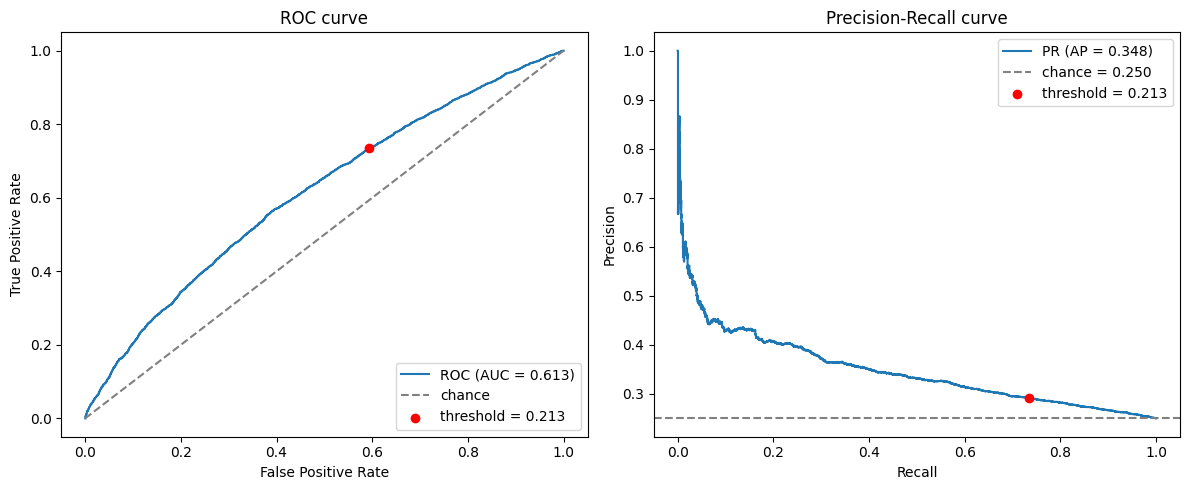

ROC-AUC = 0.6132   PR-AUC (AP) = 0.3485   base rate = 0.250
At threshold 0.213:  precision=0.292  recall=0.735  TPR=0.735  FPR=0.593


In [153]:
# === 7.6  ROC and Precision-Recall curves (final model, OOF probabilities) ===
from sklearn.metrics import (roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score,
                             f1_score)

y_true = y.values if hasattr(y, "values") else np.asarray(y)
proba  = final_result["oof"]          # OOF predicted probabilities, final model
thr    = final_result["threshold"]    # F1-optimal threshold (~0.213)

fpr, tpr, _ = roc_curve(y_true, proba)
roc_auc     = roc_auc_score(y_true, proba)
prec, rec, pr_thr = precision_recall_curve(y_true, proba)
pr_auc      = average_precision_score(y_true, proba)
base_rate   = y_true.mean()

# operating point of the chosen threshold
y_hat = (proba >= thr).astype(int)
tp = int(((y_hat==1)&(y_true==1)).sum()); fp = int(((y_hat==1)&(y_true==0)).sum())
fn = int(((y_hat==0)&(y_true==1)).sum()); tn = int(((y_hat==0)&(y_true==0)).sum())
op_tpr, op_fpr = tp/(tp+fn), fp/(fp+tn)
op_prec, op_rec = tp/(tp+fp), tp/(tp+fn)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
ax[0].plot([0,1],[0,1], "--", color="grey", label="chance")
ax[0].scatter([op_fpr],[op_tpr], color="red", zorder=5, label=f"threshold = {thr:.3f}")
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC curve"); ax[0].legend(loc="lower right")

ax[1].plot(rec, prec, label=f"PR (AP = {pr_auc:.3f})")
ax[1].axhline(base_rate, ls="--", color="grey", label=f"chance = {base_rate:.3f}")
ax[1].scatter([op_rec],[op_prec], color="red", zorder=5, label=f"threshold = {thr:.3f}")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve"); ax[1].legend(loc="upper right")
plt.tight_layout(); plt.show()

print(f"ROC-AUC = {roc_auc:.4f}   PR-AUC (AP) = {pr_auc:.4f}   base rate = {base_rate:.3f}")
print(f"At threshold {thr:.3f}:  precision={op_prec:.3f}  recall={op_rec:.3f}  "
      f"TPR={op_tpr:.3f}  FPR={op_fpr:.3f}")

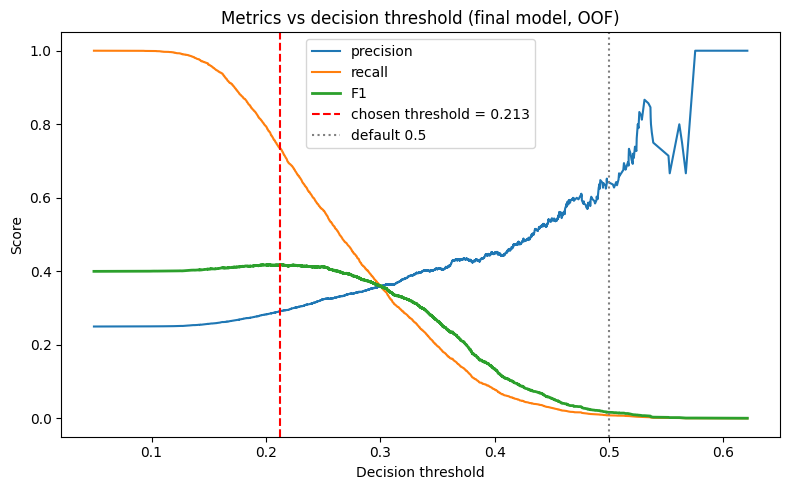

F1 at tuned threshold 0.213: 0.4182
F1 at default 0.5          : 0.0163


In [154]:
# === 7.6b  Threshold sweep: F1, precision, recall vs decision threshold ======
# precision_recall_curve returns one fewer threshold than prec/rec points.
f1_curve = 2*prec[:-1]*rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pr_thr, prec[:-1], label="precision")
ax.plot(pr_thr, rec[:-1],  label="recall")
ax.plot(pr_thr, f1_curve,  label="F1", linewidth=2)
ax.axvline(thr, ls="--", color="red",  label=f"chosen threshold = {thr:.3f}")
ax.axvline(0.5, ls=":",  color="grey", label="default 0.5")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs decision threshold (final model, OOF)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"F1 at tuned threshold {thr:.3f}: {f1_score(y_true, (proba>=thr).astype(int)):.4f}")
print(f"F1 at default 0.5          : {f1_score(y_true, (proba>=0.5).astype(int)):.4f}")


--- threshold = default 0.5 ---   F1 = 0.0163
[[10154    16]
 [ 3362    28]]
              precision    recall  f1-score   support

   non-donor      0.751     0.998     0.857     10170
       donor      0.636     0.008     0.016      3390

    accuracy                          0.751     13560
   macro avg      0.694     0.503     0.437     13560
weighted avg      0.723     0.751     0.647     13560


--- threshold = tuned 0.213 ---   F1 = 0.4182
[[4139 6031]
 [ 899 2491]]
              precision    recall  f1-score   support

   non-donor      0.822     0.407     0.544     10170
       donor      0.292     0.735     0.418      3390

    accuracy                          0.489     13560
   macro avg      0.557     0.571     0.481     13560
weighted avg      0.689     0.489     0.513     13560



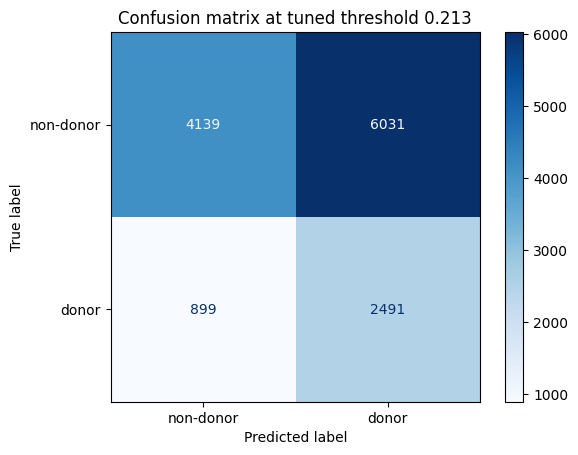

In [155]:
# === 7.6c  Confusion matrix and classification report =========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

for t, name in [(0.5, "default 0.5"), (thr, f"tuned {thr:.3f}")]:
    yp = (proba >= t).astype(int)
    print(f"\n--- threshold = {name} ---   F1 = {f1_score(y_true, yp):.4f}")
    print(confusion_matrix(y_true, yp))
    print(classification_report(y_true, yp, digits=3,
                                target_names=["non-donor", "donor"]))

ConfusionMatrixDisplay(confusion_matrix(y_true, (proba>=thr).astype(int)),
                       display_labels=["non-donor", "donor"]).plot(cmap="Blues")
plt.title(f"Confusion matrix at tuned threshold {thr:.3f}"); plt.show()

### Reading the diagnostics

**ROC curve (AUC = 0.613).** The curve sits modestly above the diagonal: the model ranks a random donor
above a random non-donor about 61% of the time — real but weak separation, consistent with the performance
plateau of Section 7. Note how *forgiving* ROC is here: because non-donors outnumber donors ~3:1, the
false-positive rate stays visually low even when many non-donors are misclassified. This optimism is
exactly why we never steered the project by ROC-AUC.

**Precision-Recall curve (AP = 0.348).** This is the honest view under imbalance. The baseline a random
classifier reaches is the donor base rate (0.250, dashed line); our average precision of 0.348 is ~1.4×
that — a genuine but limited lift. The curve falls steeply: high precision exists only at very low recall,
and raising recall quickly drags precision back toward the base rate. No operating point offers both high
precision *and* high recall — the data does not contain that much separating signal.

**Metrics vs threshold.** This plot makes the threshold decision explicit. As the threshold rises,
precision (blue) increases and recall (orange) falls; F1 (green), their harmonic mean, is **flat across a
wide low band (~0.05-0.25) and peaks near 0.21** — our chosen threshold (red dashed) sits on that peak. At
the **default 0.5** (dotted) recall has nearly vanished and F1 has collapsed: the model's probabilities
cluster around the 0.25 base rate and rarely exceed 0.5, so a 0.5 cut would predict almost no donors. The
jagged precision spikes toward 1.0 on the right are small-sample noise (very few points are predicted
positive there). Threshold tuning is therefore not optional for an imbalanced target — the default would
discard most of the model's usefulness.

**Confusion matrix at threshold 0.213.** TP = 2491, FP = 6031, FN = 899, TN = 4139 → precision 0.29,
recall 0.73, F1 0.418, the F1-optimal point. The model casts a **wide net**: it predicts 8 522 donors
(≈ 63% of the sample) to recover 2 491 of the 3 390 true donors (73% recall), at the cost of 6 031 false
positives. This is precisely the ~63% predicted-donor rate seen at deployment, but the
behaviour F1 *rewards* for a weak classifier: with little separating signal, maximising F1 means accepting
many false positives to capture most true donors.

**Business implication (motivates the open-ended section).** F1 weights precision and recall equally, but
the CSA's stated goal — "contact fewer people, the right ones" — is really a *precision* objective. The
precision-recall curve shows the lever: raising the threshold trades recall for precision, i.e. a smaller,
higher-yield contact list. We take up this trade-off, and the choice of an operating point aligned with the
charity's costs, in the open-ended section.

## 8. Deployment

We refit the chosen pipeline on all training data and predict the test set. The decision threshold is the
one tuned on out-of-fold predictions during cross-validation (~0.21), never re-tuned on the test set.
Predictions are aligned to the submission template's CONTROL_NUMBER order.

In [156]:
sample_submission_path = lab_root / "data" / "sample_submission.csv"

# Refit the final pipeline on ALL training data.
final_pipeline = Pipeline([("prep", preprocessor_for(final_features)), ("model", clone(final_model))])
final_pipeline.fit(X[final_features], y)

# Predict the (already cleaned + engineered) test set; apply the OOF-tuned threshold.
threshold  = final_result["threshold"]
test_proba = final_pipeline.predict_proba(test[final_features])[:, 1]
test_pred  = (test_proba >= threshold).astype(int)
print(f"Threshold {threshold:.3f} | predicted donor rate {test_pred.mean():.3f} (train rate {y.mean():.3f})")

# Build the submission aligned to the template's row order.
sample = pd.read_csv(sample_submission_path)
submission = pd.DataFrame({"CONTROL_NUMBER": test.index, "TARGET_B": test_pred})
submission = sample[["CONTROL_NUMBER"]].merge(submission, on="CONTROL_NUMBER", how="left")
assert submission["TARGET_B"].notna().all(), "Some test rows have no prediction."
submission["TARGET_B"] = submission["TARGET_B"].astype(int)

out_path = lab_root / "data" / "DSML_Group11.csv"
submission.to_csv(out_path, index=False)
print(submission["TARGET_B"].value_counts().to_string())
print("Saved:", out_path)
# from google.colab import files; files.download(str(out_path))   # uncomment to download

Threshold 0.213 | predicted donor rate 0.629 (train rate 0.250)
TARGET_B
1    3653
0    2159
Saved: data/DSML_Group11.csv


/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [157]:
# Is 63% a bug or the F1-optimal operating point? Compare the TRAIN OOF predicted-positive rate at the
# same threshold (should be close to the test rate if there is no train/test distribution shift).
print(f"Train OOF predicted-positive rate @ thr {threshold:.3f}: {(final_result['oof'] >= threshold).mean():.3f}")
print(f"Test     predicted-positive rate @ thr {threshold:.3f}: {test_pred.mean():.3f}")
# Context: trivial 'predict everyone' has F1 = 0.40; a weak model maximises F1 with a low threshold
# (high recall), so a high predicted-positive rate is expected here.

Train OOF predicted-positive rate @ thr 0.213: 0.628
Test     predicted-positive rate @ thr 0.213: 0.629


## 9. Open-Ended Section — From prediction to decision

### Objective and motivation

Sections 7-8 produced a classifier and a deployment cut-off chosen to **maximise F1**. But the CSA's actual
problem is not "maximise F1" — it is operational: *contact fewer people, the right ones*. F1 weights precision and recall equally and is blind to the real asymmetry between the cost of a
wasted solicitation and the value of a captured donor.

**Our objective is to turn the model's outputs into a defensible contact decision.** This has two linked
parts:

1. **Calibration.** A cost-based decision rule only makes sense if the predicted probabilities are
   trustworthy as probabilities (if the model says 0.30, ~30% of such people should actually donate). We
   assess calibration (reliability curve, Brier score) and, if needed, correct it (isotonic / sigmoid),
   evaluating everything out-of-fold.

2. **Cost-sensitive threshold.** With calibrated probabilities, the expected value of contacting a person
   with probability *p* is positive exactly when *p ≥ cost / value*. This yields a **business-optimal
   threshold**, which we compare with the F1-optimal 0.213, add a sensitivity analysis over the cost
   assumptions, and turn into a concrete contact-list recommendation.

This goes beyond tuning the pipeline: it reframes the output as a decision under asymmetric costs — the
question the CSA actually faces.

/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/keni/dev/nova/machine-learning/ml-donors-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

Brier score (lower = better):
  LogReg (uncalibrated)     0.1814
  + isotonic                0.1816
  + sigmoid                 0.1814


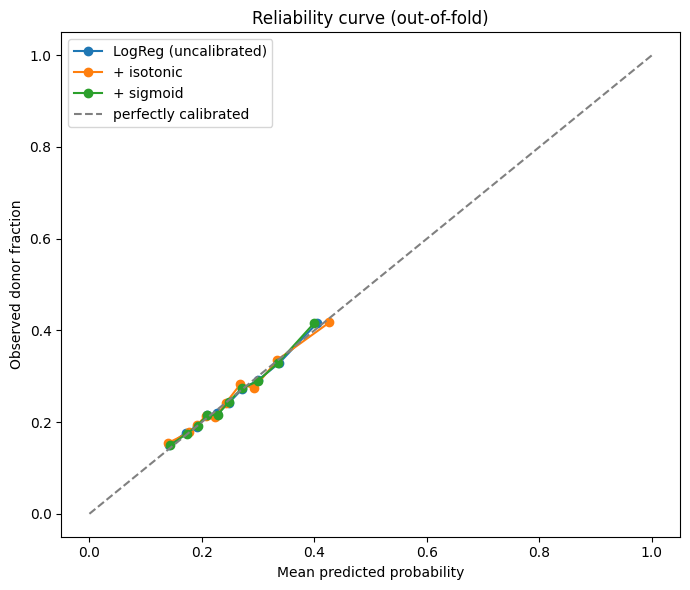

In [158]:
# === 9.1  Calibration: are the predicted probabilities trustworthy? ==========
# The business decision below relies on probabilities meaning what they say (a "p = 0.30"
# should imply ~30% of such people donate). We assess calibration with a reliability curve
# and the Brier score, then test whether post-hoc calibration (isotonic / sigmoid) helps.
# All probabilities are out-of-fold — for the calibrated variants we use NESTED CV
# (outer skf for honest evaluation, inner skf_search to fit the calibrator) -> no leakage.

y_true   = y.values if hasattr(y, "values") else np.asarray(y)
base_oof = final_result["oof"]      # uncalibrated LogReg, 5-fold OOF (Section 7.3)
base_pipe = Pipeline([("prep", preprocessor_for(final_features)), ("model", clone(final_model))])

iso_oof = cross_val_predict(CalibratedClassifierCV(base_pipe, method="isotonic", cv=skf_search),
                            X[final_features], y, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]
sig_oof = cross_val_predict(CalibratedClassifierCV(base_pipe, method="sigmoid",  cv=skf_search),
                            X[final_features], y, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

variants = {"LogReg (uncalibrated)": base_oof, "+ isotonic": iso_oof, "+ sigmoid": sig_oof}

print("Brier score (lower = better):")
for name, p in variants.items():
    print(f"  {name:24s}  {brier_score_loss(y_true, p):.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
for name, p in variants.items():
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed donor fraction")
ax.set_title("Reliability curve (out-of-fold)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### Calibration — results

All three variants lie almost exactly on the diagonal, and the Brier scores are effectively identical
(uncalibrated 0.1814, sigmoid 0.1814, isotonic 0.1816 — marginally *worse*, the usual mild overfitting of
isotonic on finite data). **Logistic regression is already well calibrated**, as expected from a model that
optimises log-loss (a proper scoring rule): its raw outputs can be read as probabilities. For reference,
always predicting the base rate (0.25) gives a Brier of ~0.1875, so the model's 0.1814 is a real but modest
improvement — consistent with the performance plateau.

Two consequences. First, the curve only spans ~0.14-0.42 because the model's probabilities cluster near the
0.25 base rate (the same fact behind the wide-net behaviour in Section 7.6) — but this is exactly the range
the decision operates in, so calibration is verified where it matters. Second, **no calibration layer is
needed**: we apply the cost-based rule directly to the native probabilities, keeping the pipeline simple.

                        rule  threshold  contacted   pct  precision  recall  net_value
value-optimal (R=4, t=0.250)      0.250       5934 0.438      0.324   0.567     1750.0
        F1-optimal (t=0.213)      0.213       8522 0.628      0.292   0.735     1442.0

The F1 threshold 0.213 implicitly assumes a donor is worth 1/0.213 = 4.7 contacts.


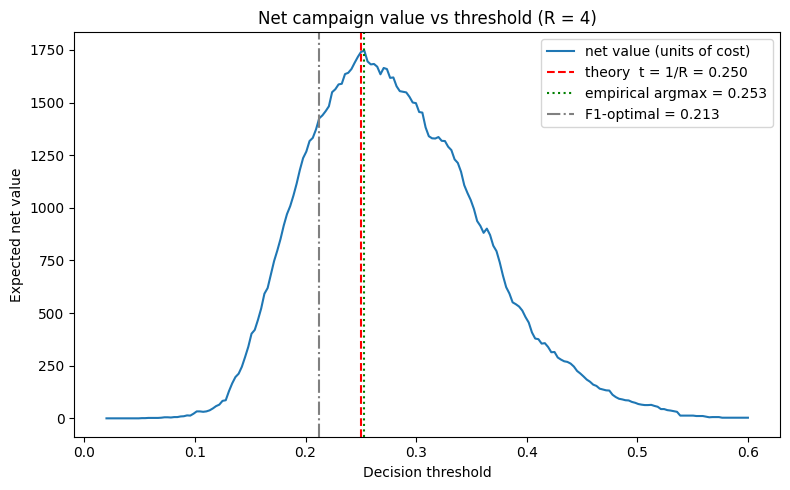

In [159]:
# === 9.2  Cost-sensitive threshold: from probabilities to a contact decision ==
# Decision rule: contact person i iff the expected value of contacting is non-negative,
#   p_i * VALUE - COST >= 0   <=>   p_i >= COST / VALUE.
# With calibrated probabilities (verified in 9.1) this cost ratio IS the optimal threshold.
# We use the out-of-fold probabilities, in units of "cost per contact" (COST=1), so a
# captured donor worth R solicitations means VALUE = R and the optimal threshold is 1/R.
proba_dec = base_oof          # native LogReg probabilities (calibration added nothing in 9.1)
n_pos = int((y_true == 1).sum())

def campaign(proba, y_true, threshold, value, cost=1.0):
    contacted = proba >= threshold
    n  = int(contacted.sum())
    tp = int((contacted & (y_true == 1)).sum())
    return dict(threshold=round(threshold, 3), contacted=n, pct=round(n/len(y_true), 3),
                precision=round(tp/n, 3) if n else 0.0, recall=round(tp/n_pos, 3),
                net_value=round(value*tp - cost*n, 1))

# Concrete scenario: a captured donor is worth R = 4 solicitations -----------------
R = 4.0
t_cost = 1.0 / R                       # value-optimal threshold
t_f1   = final_result["threshold"]     # F1-optimal threshold (~0.213)

scenario = pd.DataFrame([
    {"rule": f"value-optimal (R={R:g}, t={t_cost:.3f})", **campaign(proba_dec, y_true, t_cost, R)},
    {"rule": f"F1-optimal (t={t_f1:.3f})",               **campaign(proba_dec, y_true, t_f1,   R)},
])
print(scenario.to_string(index=False))
print(f"\nThe F1 threshold {t_f1:.3f} implicitly assumes a donor is worth 1/{t_f1:.3f} = "
      f"{1/t_f1:.1f} contacts.")

# Empirical check: net value vs threshold should peak at COST/VALUE = 1/R -----------
ts = np.linspace(0.02, 0.6, 200)
nv = [R*int(((proba_dec >= t) & (y_true == 1)).sum()) - int((proba_dec >= t).sum()) for t in ts]
t_emp = ts[int(np.argmax(nv))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ts, nv, label="net value (units of cost)")
ax.axvline(t_cost, ls="--", color="red",   label=f"theory  t = 1/R = {t_cost:.3f}")
ax.axvline(t_emp,  ls=":",  color="green",  label=f"empirical argmax = {t_emp:.3f}")
ax.axvline(t_f1,   ls="-.", color="grey",   label=f"F1-optimal = {t_f1:.3f}")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Expected net value")
ax.set_title(f"Net campaign value vs threshold (R = {R:g})"); ax.legend()
plt.tight_layout(); plt.show()

In [160]:
# === 9.2b  Sensitivity: how the contact list changes with the cost ratio R ====
# R = value of a captured donor in units of cost per contact. Lower R (contacts relatively
# costly -> donor-fatigue / "respect" concerns) -> higher threshold -> smaller, sharper list.
rows = [{"R (value/cost)": R, **campaign(proba_dec, y_true, 1.0/R, R)} for R in [2, 3, 4, 6, 10, 20]]
sweep = pd.DataFrame(rows)
print(sweep[["R (value/cost)", "threshold", "pct", "contacted", "precision", "recall"]].to_string(index=False))

 R (value/cost)  threshold   pct  contacted  precision  recall
              2      0.500 0.003         44      0.636   0.008
              3      0.333 0.159       2152      0.395   0.251
              4      0.250 0.438       5934      0.324   0.567
              6      0.167 0.871      11817      0.263   0.918
             10      0.100 0.997      13522      0.251   0.999
             20      0.050 1.000      13559      0.250   1.000


### Cost-sensitive threshold — results

**The rule works.** The net-value curve peaks at the empirical threshold 0.253, essentially on top of the
theoretical optimum 1/R = 0.250 — the operational payoff of the calibration check in 9.1: because the
probabilities are trustworthy, "contact iff p ≥ cost/value" really does maximise value.

**Aligning the threshold with economics helps on both fronts.** At R = 4 (a captured donor worth four
solicitations) the value-optimal cut contacts 5 934 people versus 8 522 under the F1 threshold — about
2 600 fewer solicitations — while reaching higher precision (0.32 vs 0.29) and ~21% more net value
(1 750 vs 1 442). The charity's two goals — *contact fewer people* and *spend wisely* — are not in tension
here: the same move achieves both. Recall does drop (0.57 vs 0.74), the deliberate trade: we forgo
hard-to-reach donors rather than blanket-soliciting.

**F1 is not neutral.** The F1-optimal 0.213 implicitly assumes a donor is worth 1/0.213 ≈ 4.7 contacts.
Optimising F1 silently fixes the economics; the cost framing lets CSA set them explicitly. The sensitivity
table is the single lever: as contacts become relatively costlier (lower R — the donor-fatigue concern at
the heart of this project), the threshold rises and the list shrinks, from the whole base (R ≥ 10) down to
44 ultra-targeted contacts (R = 2).

**Honest limit.** Even at the most selective end, precision tops out around 0.64 (R = 2), not near 1.0: the
weak signal documented throughout (the performance plateau) means there is no near-pure pocket of donors.
The model *concentrates* donors — it cannot *isolate* them. The value gained comes from dropping
low-probability contacts, not from finding a perfect segment.

### Action plan for the CSA

Our analysis turns the classifier into an operating policy:

1. **Choose the economics, not the metric.** Estimate two quantities from a pilot or historical data: the
   expected value of a captured donor and the all-in cost of one solicitation (postage *plus* the intangible
   cost of the donor fatigue this project exists to reduce). Their ratio R sets the contact threshold at
   1/R — no model retraining required.
2. **Contact by priority.** Score the candidate pool with the deployed pipeline, rank by probability, and
   contact downward until the threshold (or the budget) is reached. The ranking doubles as a priority list
   when budget is the binding constraint.
3. **Start conservative.** Given the project's premise (over-solicitation is the problem), a low-to-moderate
   R is appropriate. For illustration, R = 4 contacts the top ~44% of the pool, reaches ~57% of donors, and
   removes ~2 600 wasted solicitations relative to an F1-driven list.
4. **Set expectations.** With precision peaking near 0.64, the tool triages — it concentrates outreach on
   the most promising supporters; it does not identify donors with certainty. Track realised
   precision/recall per campaign and re-estimate R as evidence accumulates.
